# Frequency-dependent assessment of an Obit MFImage cuboid

## Purpose

This reusable notebook assesses the non-PB MFS Image, spectral-index plane and
independent frequency subbands in a non-primary-beam-corrected Obit/MFImage FITS file.
The observation CBID, target name, optional PB-corrected companion and output paths are
derived/extracted from the input FITS path.

The notebook writes observation-specific metrics CSVs, diagnostic PNGs, a JSON
summary and a code-free PDF report to:

`<parent of images>/mfimage_frequency_assessment/`

Every generated filename starts with the derived CBID. Use `INPUT_FITS` for one
cuboid, or `INPUT_FITS_GLOB` to assess multiple cuboids one by one. The equivalent
environment variables are `MFIMAGE_FITS` and `MFIMAGE_FITS_GLOB`.

The analysis deliberately separates:

1. the non-PB MFS Image at the reference frequency;
2. the SNR-dependent spectral-index product; and
3. the independent subband images that provide the actual frequency diagnostic.

## Context & Methods

The image formats are interpreted from `MFImage.pdf` (Obit Development Memo 63):

- plane 0: fitted flux density at the reference frequency;
- plane 1: fitted or default spectral index when `NTERM >= 2`;
- planes starting at `NTERM`: independent, approximately
  constant-fractional-bandwidth subband images.

The subband frequencies are read from `FEFFnnnn`; they must not be inferred from a
linear FITS axis because MFImage subbands need not be equally spaced.

### Key assumptions

- The image is Stokes I in Jy/beam and the subbands use the restoring beam recorded
  in the primary header.
- Robust noise estimates use iterative 5-sigma clipping on a spatially sampled image.
- The central annulus measures bright-source-associated structure while excluding
  the restored source core. The outer annulus supplies a source-sparse comparison.
- `SEVERE_RMS_THRESHOLD_MJY` is a configurable diagnostic threshold, not a universal
  science-quality requirement.
- A PB-corrected companion is optional. When present, it is used only for a
  consistency check and does not drive the subband classification.

### Role of a PB-corrected RMS image

A continuum PB-corrected RMS map adds a spatial noise model. It allows the notebook
to distinguish PB-driven sensitivity loss from statistically significant residual
structure and to test whether the reported local noise agrees with the image pixels.
It does not identify frequency-localized corruption because it is a full-band,
two-dimensional product; the independent MFImage subbands remain the frequency
diagnostic.

## 1. User inputs and global defaults

Edit only the next code cell for a normal interactive run. Set `INPUT_FITS` for one
cuboid or set `INPUT_FITS_GLOB` for batch mode; do not set both. The same values may
be supplied through `MFIMAGE_FITS` or `MFIMAGE_FITS_GLOB`.
The remaining values are documented global defaults for sampling, masks,
classification and display behavior.

In [5]:
import glob

In [6]:
# USER INPUT
# =============================================================================
# Single-file mode: set the absolute path of one non-PB MFImage IClean cuboid.
# Leave as None to read MFIMAGE_FITS, or when using INPUT_FITS_GLOB below.
PWD        = "/Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/"

## Example: INPUT_FITS = PWD + "1783842626_8kS/images/1783842626_continuum_image_J2147-8132_IClean.fits"
CBID       = "1787034555"
INPUT_FITS = glob.glob( PWD + f"{CBID}_*k*/images/{CBID}_continuum_image_J2147-8132_IClean.fits" )[0] #None 
BATCH_MODE = True

# Batch mode: set INPUT_FITS=None and supply an absolute or relative glob pattern.
# Recursive ** patterns are supported. PB, RMS and background FITS products are
# excluded automatically. Leave as None to read MFIMAGE_FITS_GLOB.
if BATCH_MODE and INPUT_FITS is None:
    INPUT_FITS_GLOB = PWD + "**/images/*_continuum_image_J2147-8132_IClean.fits"
else:
    INPUT_FITS_GLOB = None

# Optional PB-corrected RMS and background images. Leave as None to use
# conventional companion filenames beside INPUT_FITS. Explicit overrides are
# supported only in single-file mode; batch mode discovers companions per cuboid.
PB_RMS_FITS        = None
PB_BACKGROUND_FITS = None

In [7]:
# GLOBAL ANALYSIS DEFAULTS
# =============================================================================
# Timezone used for the analysis timestamp written to outputs.
ANALYSIS_TIMEZONE = "Africa/Johannesburg"

# Memory-bounded spatial sampling and central diagnostic crop.
DISPLAY_STRIDE      = 4
CENTRAL_CROP_DEG    = 0.32
CENTRAL_CROP_STRIDE = 2

# Robust-statistics controls.
ROBUST_CLIP_ITERATIONS = 5
ROBUST_CLIP_SIGMA      = 5.0 ## 5-sigma clipping prevents bright sources and extreme artifact 
                             ## pixels from dominating the estimate of the underlying image noise.

# Radial masks, measured from the FITS phase centre.
CENTRAL_ANNULUS_INNER_DEG    = 0.015
CENTRAL_ANNULUS_OUTER_DEG    = 0.10
BACKGROUND_ANNULUS_INNER_DEG = 0.25
BACKGROUND_ANNULUS_OUTER_DEG = 0.50
SCIENCE_FIELD_RADIUS_DEG     = 0.75
RADIAL_PROFILE_EDGES_DEG     = (0.00, 0.10, 0.25, 0.50, 0.75, 0.95)

# Source and frequency-assessment controls.
PEAK_SEARCH_RADIUS_DEG   = 0.03
SEVERE_RMS_THRESHOLD_MJY = 10.0
PATTERN_CLIP_JY          = 0.01
ALPHA_SNR_MIN            = 10.0

# PB-corrected RMS analysis. If no RMS FITS is found, estimate a robust
# local RMS map from the PB image and optional background map.
ESTIMATE_PB_RMS_IF_MISSING = True
RMS_ESTIMATION_TILE_PIXELS = 128
NORMALIZED_RESIDUAL_LIMIT  = 10.0

# Figure and histogram defaults. FIGURE_FONT_SIZE is the base point size used
# for figure text, titles, legends, tick labels and axis labels.
FIGURE_FONT_SIZE        = 10.0
COMMON_DISPLAY_LIMIT_MJY = 5.0
SIGMA_DISPLAY_LIMIT      = 8.0
ALPHA_MAP_MIN            = -2.5
ALPHA_MAP_MAX            = 0.5
ALPHA_HISTOGRAM_MIN      = -3.0
ALPHA_HISTOGRAM_MAX      = 2.0
ALPHA_HISTOGRAM_BINS     = 70
MAX_SUBBAND_COLUMNS      = 3
FIGURE_DPI               = 300

### 2. Initialize paths and plotting

This cell validates the selected input, derives the CBID, target, optional PB
companion and observation-local output directory, then establishes plotting styles.
It normally does not need editing.

In [8]:
## Live code
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import glob as glob_module
import json
import os
import re
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LogNorm, SymLogNorm
from astropy.io import fits
from IPython.display import FileLink, Markdown, display

warnings.filterwarnings("ignore", category=RuntimeWarning)

ANALYSIS_TIMESTAMP = datetime.now(ZoneInfo(ANALYSIS_TIMEZONE))
ANALYSIS_TIMESTAMP_ISO = ANALYSIS_TIMESTAMP.isoformat(timespec="seconds")
ANALYSIS_DATE = ANALYSIS_TIMESTAMP.date().isoformat()
ANALYSIS_TIMEZONE_ABBREVIATION = ANALYSIS_TIMESTAMP.tzname() or ANALYSIS_TIMEZONE

batch_child_input = globals().get("_BATCH_CURRENT_INPUT")
single_input_value = (
    batch_child_input or INPUT_FITS or os.environ.get("MFIMAGE_FITS")
)
glob_input_value = (
    None if batch_child_input
    else INPUT_FITS_GLOB or os.environ.get("MFIMAGE_FITS_GLOB")
)
if single_input_value and glob_input_value:
    raise RuntimeError(
        "Set only one of INPUT_FITS/MFIMAGE_FITS or "
        "INPUT_FITS_GLOB/MFIMAGE_FITS_GLOB."
    )
if not single_input_value and not glob_input_value:
    raise RuntimeError(
        "Set INPUT_FITS for one cuboid or INPUT_FITS_GLOB for batch mode; "
        "the MFIMAGE_FITS and MFIMAGE_FITS_GLOB environment variables are "
        "also supported."
    )

BATCH_MODE = bool(glob_input_value)
if BATCH_MODE:
    matched_paths = sorted({
        Path(value).expanduser().resolve()
        for value in glob_module.glob(glob_input_value, recursive=True)
    })
    BATCH_INPUT_PATHS = [
        path for path in matched_paths
        if path.is_file()
        and path.suffix.lower() in {".fits", ".fit", ".fts"}
        and "_IClean" in path.stem
        and "_PB" not in path.stem
    ]
    if not BATCH_INPUT_PATHS:
        raise FileNotFoundError(
            f"No non-PB MFImage IClean FITS cuboids matched: {glob_input_value}"
        )
    if any((PB_RMS_FITS, PB_BACKGROUND_FITS,
            os.environ.get("MFIMAGE_PB_RMS_FITS"),
            os.environ.get("MFIMAGE_PB_BACKGROUND_FITS"))):
        raise RuntimeError(
            "Explicit PB RMS/background overrides are single-file options. "
            "Leave them unset in batch mode so companions are found per cuboid."
        )
else:
    BATCH_INPUT_PATHS = [Path(single_input_value).expanduser().resolve()]

CUBOID_PATH = BATCH_INPUT_PATHS[0]
if not CUBOID_PATH.is_file():
    raise FileNotFoundError(CUBOID_PATH)
if CUBOID_PATH.suffix.lower() not in {".fits", ".fit", ".fts"}:
    raise ValueError(f"Expected a FITS input, received: {CUBOID_PATH.name}")
if CUBOID_PATH.stem.endswith("_PB"):
    raise ValueError("Use the non-PB IClean FITS cuboid as INPUT_FITS.")

IMAGES_DIR = CUBOID_PATH.parent
OBSERVATION_DIR = IMAGES_DIR.parent
filename_cbid = re.match(r"(?P<cbid>[0-9]+)(?:_|$)", CUBOID_PATH.name)
CBID = filename_cbid.group("cbid") if filename_cbid else OBSERVATION_DIR.name
if not CBID:
    raise ValueError("Could not derive a CBID from the filename or observation directory.")

target_match = re.search(
    r"_continuum_image_(?P<target>.+?)_IClean(?:_|\.|$)",
    CUBOID_PATH.name,
)
TARGET_NAME = target_match.group("target") if target_match else CUBOID_PATH.stem

PB_IMAGE_PATH = CUBOID_PATH.with_name(f"{CUBOID_PATH.stem}_PB{CUBOID_PATH.suffix}")
PB_AVAILABLE = PB_IMAGE_PATH.is_file()


def first_existing_path(candidates):
    return next((path for path in candidates if path.is_file()), None)


pb_rms_input = (
    None if batch_child_input
    else PB_RMS_FITS or os.environ.get("MFIMAGE_PB_RMS_FITS")
)
if pb_rms_input:
    PB_RMS_IMAGE_PATH = Path(pb_rms_input).expanduser().resolve()
    if not PB_RMS_IMAGE_PATH.is_file():
        raise FileNotFoundError(PB_RMS_IMAGE_PATH)
else:
    PB_RMS_IMAGE_PATH = first_existing_path([
        PB_IMAGE_PATH.with_name(
            f"{PB_IMAGE_PATH.stem}_aegean_rms{PB_IMAGE_PATH.suffix}"
        ),
        PB_IMAGE_PATH.with_name(f"{PB_IMAGE_PATH.stem}_rms{PB_IMAGE_PATH.suffix}"),
        PB_IMAGE_PATH.with_name(f"{PB_IMAGE_PATH.stem}-rms{PB_IMAGE_PATH.suffix}"),
    ])
PB_RMS_EXTERNAL_AVAILABLE = PB_RMS_IMAGE_PATH is not None

pb_background_input = (
    None if batch_child_input
    else PB_BACKGROUND_FITS or os.environ.get("MFIMAGE_PB_BACKGROUND_FITS")
)
if pb_background_input:
    PB_BACKGROUND_IMAGE_PATH = Path(pb_background_input).expanduser().resolve()
    if not PB_BACKGROUND_IMAGE_PATH.is_file():
        raise FileNotFoundError(PB_BACKGROUND_IMAGE_PATH)
else:
    PB_BACKGROUND_IMAGE_PATH = first_existing_path([
        PB_IMAGE_PATH.with_name(
            f"{PB_IMAGE_PATH.stem}_aegean_bkg{PB_IMAGE_PATH.suffix}"
        ),
        PB_IMAGE_PATH.with_name(
            f"{PB_IMAGE_PATH.stem}_background{PB_IMAGE_PATH.suffix}"
        ),
        PB_IMAGE_PATH.with_name(f"{PB_IMAGE_PATH.stem}_bkg{PB_IMAGE_PATH.suffix}"),
    ])
PB_BACKGROUND_AVAILABLE = PB_BACKGROUND_IMAGE_PATH is not None

OUTPUT_DIR = OBSERVATION_DIR / "mfimage_frequency_assessment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def output_path(suffix):
    return OUTPUT_DIR / f"{CBID}_{suffix}"

INK = "#172026"
MUTED = "#68737D"
GRID = "#DCE1E5"
BLUE = "#1F5A94"
ORANGE = "#C66A19"
GOLD = "#D4A72C"
PALE_BLUE = "#DCEAF5"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": FIGURE_FONT_SIZE,
    "axes.titlesize": 1.1 * FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "xtick.labelsize": 0.9 * FIGURE_FONT_SIZE,
    "ytick.labelsize": 0.9 * FIGURE_FONT_SIZE,
    "legend.fontsize": 0.9 * FIGURE_FONT_SIZE,
    "figure.titlesize": 1.4 * FIGURE_FONT_SIZE,
    "legend.frameon": False,
    "savefig.facecolor": "white",
})

display(Markdown(
    f"**Analysis timestamp:** `{ANALYSIS_TIMESTAMP_ISO}`  \n"
    f"**Input mode:** {'batch' if BATCH_MODE else 'single cuboid'}"
    + (f" ({len(BATCH_INPUT_PATHS)} matched cuboids)" if BATCH_MODE else "")
    + "  \n"
    f"**Observation:** `{CBID}`  \n"
    f"**Target:** `{TARGET_NAME}`  \n"
    f"**Input:** `{CUBOID_PATH}`  \n"
    f"**Output directory:** `{OUTPUT_DIR}`  \n"
    f"**PB companion:** "
    + (f"`{PB_IMAGE_PATH.name}`" if PB_AVAILABLE else "not found; PB checks will be skipped")
    + "  \n**PB RMS:** "
    + (
        f"`{PB_RMS_IMAGE_PATH.name}`"
        if PB_RMS_EXTERNAL_AVAILABLE
        else "not found; a robust local estimate will be used"
        if PB_AVAILABLE and ESTIMATE_PB_RMS_IF_MISSING
        else "not available"
    )
    + "  \n**PB background:** "
    + (
        f"`{PB_BACKGROUND_IMAGE_PATH.name}`"
        if PB_BACKGROUND_AVAILABLE
        else "not found"
    )
))

**Analysis timestamp:** `2026-08-19T10:03:13+02:00`  
**Input mode:** single cuboid  
**Observation:** `1787034555`  
**Target:** `J2147-8132`  
**Input:** `/Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/images/1787034555_continuum_image_J2147-8132_IClean.fits`  
**Output directory:** `/Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment`  
**PB companion:** `1787034555_continuum_image_J2147-8132_IClean_PB.fits`  
**PB RMS:** `1787034555_continuum_image_J2147-8132_IClean_PB_aegean_rms.fits`  
**PB background:** not found

### 3. Validate the MFImage structure

The most important validity check is `NAXIS3 = NTERM + NSPEC`. A conventional linear interpretation of axis 3 would be wrong for this product.

In [9]:
## Live code
if "cuboid_hdul" in globals():
    cuboid_hdul.close()

cuboid_hdul = fits.open(CUBOID_PATH, memmap=True, do_not_scale_image_data=True)
primary_header = cuboid_hdul[0].header
raw_cube = cuboid_hdul[0].data
image_planes = raw_cube[0]

NTERM = int(primary_header["NTERM"])
NSPEC = int(primary_header["NSPEC"])
REFERENCE_FREQUENCY_HZ = float(primary_header["RFALPHA"])
SUBBAND_FREQUENCIES_HZ = np.array([
    float(primary_header[f"FEFF{index:04d}"])
    for index in range(1, NSPEC + 1)
])

assert primary_header["CTYPE3"].strip() == "SPECLNMF"
assert image_planes.shape[0] == NTERM + NSPEC
assert NTERM >= 2, "This analysis requires fitted intensity and spectral-index planes."


def first_header_value(header, keys, default="not recorded"):
    for key in keys:
        value = header.get(key)
        if value not in (None, ""):
            return value, key
    return default, None


TELESCOPE, TELESCOPE_SOURCE_KEY = first_header_value(
    primary_header,
    ("TELESCOP", "TELESCOPE"),
)
INSTRUMENT_MODE, INSTRUMENT_SOURCE_KEY = first_header_value(
    primary_header,
    ("INSTRUME", "INSTRUMENT"),
)
OBSERVATION_OBJECT, OBJECT_SOURCE_KEY = first_header_value(
    primary_header,
    ("OBJECT",),
    TARGET_NAME,
)
OBSERVATION_DATE, OBSERVATION_DATE_SOURCE_KEY = first_header_value(
    primary_header,
    ("DATE-OBS", "DATEOBS"),
)
MAP_DATE, MAP_DATE_SOURCE_KEY = first_header_value(
    primary_header,
    ("DATE-MAP", "DATE"),
)
OBSERVER_PROJECT, OBSERVER_SOURCE_KEY = first_header_value(
    primary_header,
    ("OBSERVER", "PROJECT"),
)
BAND_CODE, BAND_SOURCE_KEY = first_header_value(
    primary_header,
    ("BANDCODE", "OBSBAND", "BAND"),
)
FITS_ORIGIN, ORIGIN_SOURCE_KEY = first_header_value(
    primary_header,
    ("ORIGIN",),
)

subband_low_edge_keys = [
    f"FREL{index:04d}" for index in range(1, NSPEC + 1)
]
subband_high_edge_keys = [
    f"FREH{index:04d}" for index in range(1, NSPEC + 1)
]
if all(key in primary_header for key in subband_low_edge_keys + subband_high_edge_keys):
    FREQUENCY_MIN_HZ = min(
        float(primary_header[key]) for key in subband_low_edge_keys
    )
    FREQUENCY_MAX_HZ = max(
        float(primary_header[key]) for key in subband_high_edge_keys
    )
    FREQUENCY_RANGE_SOURCE = "FRELnnnn/FREHnnnn subband edges"
else:
    FREQUENCY_MIN_HZ = float(np.nanmin(SUBBAND_FREQUENCIES_HZ))
    FREQUENCY_MAX_HZ = float(np.nanmax(SUBBAND_FREQUENCIES_HZ))
    FREQUENCY_RANGE_SOURCE = (
        "FEFFnnnn effective centres; edge keywords unavailable"
    )

CLEAN_BEAM_MAJOR_DEG, CLEAN_BEAM_MAJOR_SOURCE_KEY = first_header_value(
    primary_header,
    ("CLEANBMJ", "BMAJ"),
    np.nan,
)
CLEAN_BEAM_MINOR_DEG, CLEAN_BEAM_MINOR_SOURCE_KEY = first_header_value(
    primary_header,
    ("CLEANBMN", "BMIN"),
    np.nan,
)
CLEAN_BEAM_PA_DEG, CLEAN_BEAM_PA_SOURCE_KEY = first_header_value(
    primary_header,
    ("CLEANBPA", "BPA"),
    np.nan,
)
CLEAN_BEAM_MAJOR_DEG = float(CLEAN_BEAM_MAJOR_DEG)
CLEAN_BEAM_MINOR_DEG = float(CLEAN_BEAM_MINOR_DEG)
CLEAN_BEAM_PA_DEG = float(CLEAN_BEAM_PA_DEG)
CLEAN_BEAM_MAJOR_ARCSEC = CLEAN_BEAM_MAJOR_DEG * 3600.0
CLEAN_BEAM_MINOR_ARCSEC = CLEAN_BEAM_MINOR_DEG * 3600.0
CLEAN_ITERATIONS, CLEAN_ITERATIONS_SOURCE_KEY = first_header_value(
    primary_header,
    ("CLEANNIT",),
)

FREQUENCY_MIN_MHZ = FREQUENCY_MIN_HZ / 1e6
FREQUENCY_MAX_MHZ = FREQUENCY_MAX_HZ / 1e6
FREQUENCY_RANGE_TEXT = (
    f"{FREQUENCY_MIN_MHZ:.3f}-{FREQUENCY_MAX_MHZ:.3f} MHz "
    f"({FREQUENCY_MIN_MHZ / 1e3:.6f}-{FREQUENCY_MAX_MHZ / 1e3:.6f} GHz)"
)
CLEAN_BEAM_TEXT = (
    f"{CLEAN_BEAM_MAJOR_ARCSEC:.3f} x "
    f"{CLEAN_BEAM_MINOR_ARCSEC:.3f} arcsec, "
    f"PA {CLEAN_BEAM_PA_DEG:.6f} deg"
)

OBSERVATION_METADATA_PATH = output_path("observation_metadata.csv")
observation_metadata_rows = [
    {
        "field": "Analysis timestamp",
        "value": ANALYSIS_TIMESTAMP_ISO,
        "unit": "",
        "source": f"runtime clock ({ANALYSIS_TIMEZONE})",
    },
    {
        "field": "CBID",
        "value": CBID,
        "unit": "",
        "source": "input filename or observation directory",
    },
    {
        "field": "Object",
        "value": OBSERVATION_OBJECT,
        "unit": "",
        "source": OBJECT_SOURCE_KEY or "input filename",
    },
    {
        "field": "Telescope",
        "value": TELESCOPE,
        "unit": "",
        "source": TELESCOPE_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Instrument / correlator mode",
        "value": INSTRUMENT_MODE,
        "unit": "",
        "source": INSTRUMENT_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Band code",
        "value": BAND_CODE,
        "unit": "",
        "source": BAND_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Observation date",
        "value": OBSERVATION_DATE,
        "unit": "",
        "source": OBSERVATION_DATE_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Map date",
        "value": MAP_DATE,
        "unit": "",
        "source": MAP_DATE_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Observer / project",
        "value": OBSERVER_PROJECT,
        "unit": "",
        "source": OBSERVER_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Frequency minimum",
        "value": FREQUENCY_MIN_MHZ,
        "unit": "MHz",
        "source": FREQUENCY_RANGE_SOURCE,
    },
    {
        "field": "Frequency maximum",
        "value": FREQUENCY_MAX_MHZ,
        "unit": "MHz",
        "source": FREQUENCY_RANGE_SOURCE,
    },
    {
        "field": "Reference frequency",
        "value": REFERENCE_FREQUENCY_HZ / 1e6,
        "unit": "MHz",
        "source": "RFALPHA",
    },
    {
        "field": "Clean beam major FWHM",
        "value": CLEAN_BEAM_MAJOR_ARCSEC,
        "unit": "arcsec",
        "source": CLEAN_BEAM_MAJOR_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Clean beam minor FWHM",
        "value": CLEAN_BEAM_MINOR_ARCSEC,
        "unit": "arcsec",
        "source": CLEAN_BEAM_MINOR_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Clean beam position angle",
        "value": CLEAN_BEAM_PA_DEG,
        "unit": "deg",
        "source": CLEAN_BEAM_PA_SOURCE_KEY or "not recorded",
    },
    {
        "field": "Clean iterations",
        "value": CLEAN_ITERATIONS,
        "unit": "",
        "source": CLEAN_ITERATIONS_SOURCE_KEY or "not recorded",
    },
    {
        "field": "FITS writer",
        "value": FITS_ORIGIN,
        "unit": "",
        "source": ORIGIN_SOURCE_KEY or "not recorded",
    },
]
observation_metadata = pd.DataFrame(observation_metadata_rows)
observation_metadata.to_csv(OBSERVATION_METADATA_PATH, index=False)

display(Markdown("#### Observation metadata and analysis provenance"))
display(
    observation_metadata.style.format(
        {"value": lambda value: f"{value:.9g}" if isinstance(value, float) else value}
    )
)
print(f"Saved: {OBSERVATION_METADATA_PATH}")

plane_rows = [
    {"plane": 0, "role": "non-PB MFS Image", "frequency_mhz": REFERENCE_FREQUENCY_HZ / 1e6},
    {"plane": 1, "role": "Fitted/default spectral index", "frequency_mhz": np.nan},
]
for subband_index, frequency_hz in enumerate(SUBBAND_FREQUENCIES_HZ, start=1):
    plane_rows.append({
        "plane": NTERM + subband_index - 1,
        "role": f"Independent subband {subband_index}",
        "frequency_mhz": frequency_hz / 1e6,
    })

plane_table = pd.DataFrame(plane_rows)
display(plane_table.style.format({"frequency_mhz": "{:.3f}"}))

print(f"Raw FITS shape: {raw_cube.shape}")
print(f"Spatial size: {image_planes.shape[-1]} x {image_planes.shape[-2]} pixels")
print(
    "Common restoring beam: "
    f"{primary_header['BMAJ'] * 3600:.2f} x "
    f"{primary_header['BMIN'] * 3600:.2f} arcsec, "
    f"PA {primary_header['BPA']:.2f} deg"
)
print(
    f"Reference frequency: {REFERENCE_FREQUENCY_HZ / 1e6:.3f} MHz; "
    f"NTERM={NTERM}; NSPEC={NSPEC}"
)

#### Observation metadata and analysis provenance

,field,value,unit,source
0,Analysis timestamp,2026-08-19T10:03:13+02:00,,runtime clock (Africa/Johannesburg)
1,CBID,1787034555,,input filename or observation directory
2,Object,J2147-81,,OBJECT
3,Telescope,MeerKAT,,TELESCOP
4,Instrument / correlator mode,c875M1k,,INSTRUME
5,Band code,S,,BANDCODE
6,Observation date,2026-08-18,,DATE-OBS
7,Map date,2026-08-18,,DATE-MAP
8,Observer / project,Letjatji,,OBSERVER
9,Frequency minimum,2625,MHz,FRELnnnn/FREHnnnn subband edges


Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_observation_metadata.csv


,plane,role,frequency_mhz
0,0,non-PB MFS Image,3062.073
1,1,Fitted/default spectral index,nan
2,2,Independent subband 1,2707.268
3,3,Independent subband 2,2777.137
4,4,Independent subband 3,2882.678
5,5,Independent subband 4,2991.388
6,6,Independent subband 5,3106.548
7,7,Independent subband 6,3217.332
8,8,Independent subband 7,3343.798
9,9,Independent subband 8,3426.677


Raw FITS shape: (1, 10, 7734, 7734)
Spatial size: 7734 x 7734 pixels
Common restoring beam: 5.15 x 3.83 arcsec, PA -50.04 deg
Reference frequency: 3062.073 MHz; NTERM=2; NSPEC=8


### 4. Analysis helpers and spatial masks

The functions below use robust median/MAD statistics. Bright sources and strong artifacts are iteratively clipped before the local noise floor is reported.

In [10]:
## Live code
def robust_location_scale(
    values,
    iterations=ROBUST_CLIP_ITERATIONS,
    sigma=ROBUST_CLIP_SIGMA,
):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, 0
    for _ in range(iterations):
        median = np.median(values)
        scale = 1.4826 * np.median(np.abs(values - median))
        if not np.isfinite(scale) or scale <= 0:
            break
        keep = np.abs(values - median) < sigma * scale
        if keep.sum() == values.size:
            break
        values = values[keep]
    median = np.median(values)
    scale = 1.4826 * np.median(np.abs(values - median))
    return float(median), float(scale), int(values.size)


def sampled_plane(plane_index, stride=DISPLAY_STRIDE):
    return np.asarray(image_planes[plane_index, ::stride, ::stride])


def add_panel_label(axis, label, color=INK):
    axis.text(
        0.02, 0.98, label,
        transform=axis.transAxes,
        ha="left", va="top",
        fontsize=0.9 * FIGURE_FONT_SIZE, fontweight="bold", color=color,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 2},
    )


INTENSITY_PLANE = image_planes[0]
ALPHA_PLANE = image_planes[1]
NY, NX = INTENSITY_PLANE.shape
CENTER_X = float(primary_header["CRPIX1"]) - 1.0
CENTER_Y = float(primary_header["CRPIX2"]) - 1.0
PIXEL_SCALE_DEG = abs(float(primary_header["CDELT1"]))

sample_y = np.arange(0, NY, DISPLAY_STRIDE)
sample_x = np.arange(0, NX, DISPLAY_STRIDE)
sample_y_offset_deg = (sample_y - CENTER_Y) * PIXEL_SCALE_DEG
sample_x_offset_deg = (sample_x - CENTER_X) * PIXEL_SCALE_DEG
sample_radius_deg = np.sqrt(
    sample_y_offset_deg[:, None] ** 2 + sample_x_offset_deg[None, :] ** 2
)

full_extent_deg = [
    (0 - CENTER_X) * PIXEL_SCALE_DEG,
    (NX - 1 - CENTER_X) * PIXEL_SCALE_DEG,
    (0 - CENTER_Y) * PIXEL_SCALE_DEG,
    (NY - 1 - CENTER_Y) * PIXEL_SCALE_DEG,
]

central_annulus_mask = (
    (sample_radius_deg >= CENTRAL_ANNULUS_INNER_DEG)
    & (sample_radius_deg < CENTRAL_ANNULUS_OUTER_DEG)
)
background_annulus_mask = (
    (sample_radius_deg >= BACKGROUND_ANNULUS_INNER_DEG)
    & (sample_radius_deg < BACKGROUND_ANNULUS_OUTER_DEG)
)
science_field_mask = sample_radius_deg < SCIENCE_FIELD_RADIUS_DEG

crop_half_pixels = int(np.ceil(CENTRAL_CROP_DEG / PIXEL_SCALE_DEG))
crop_x0 = max(0, int(round(CENTER_X)) - crop_half_pixels)
crop_x1 = min(NX, int(round(CENTER_X)) + crop_half_pixels + 1)
crop_y0 = max(0, int(round(CENTER_Y)) - crop_half_pixels)
crop_y1 = min(NY, int(round(CENTER_Y)) + crop_half_pixels + 1)
central_extent_deg = [
    (crop_x0 - CENTER_X) * PIXEL_SCALE_DEG,
    (crop_x1 - 1 - CENTER_X) * PIXEL_SCALE_DEG,
    (crop_y0 - CENTER_Y) * PIXEL_SCALE_DEG,
    (crop_y1 - 1 - CENTER_Y) * PIXEL_SCALE_DEG,
]

print(
    f"Display/statistics stride: {DISPLAY_STRIDE}; "
    f"background samples before clipping: {background_annulus_mask.sum():,}; "
    f"central-annulus samples before clipping: {central_annulus_mask.sum():,}"
)

Display/statistics stride: 4; background samples before clipping: 1,303,124; central-annulus samples before clipping: 67,922


## Results

### 5. Diagnostic view of the non-PB MFS Image

This reproduces the earlier diagnostic layout, now using plane 0 of the non-PB cuboid. The clipped and symmetric-log views expose low-level sidelobes without allowing the bright phase-centre source to determine the display scale.

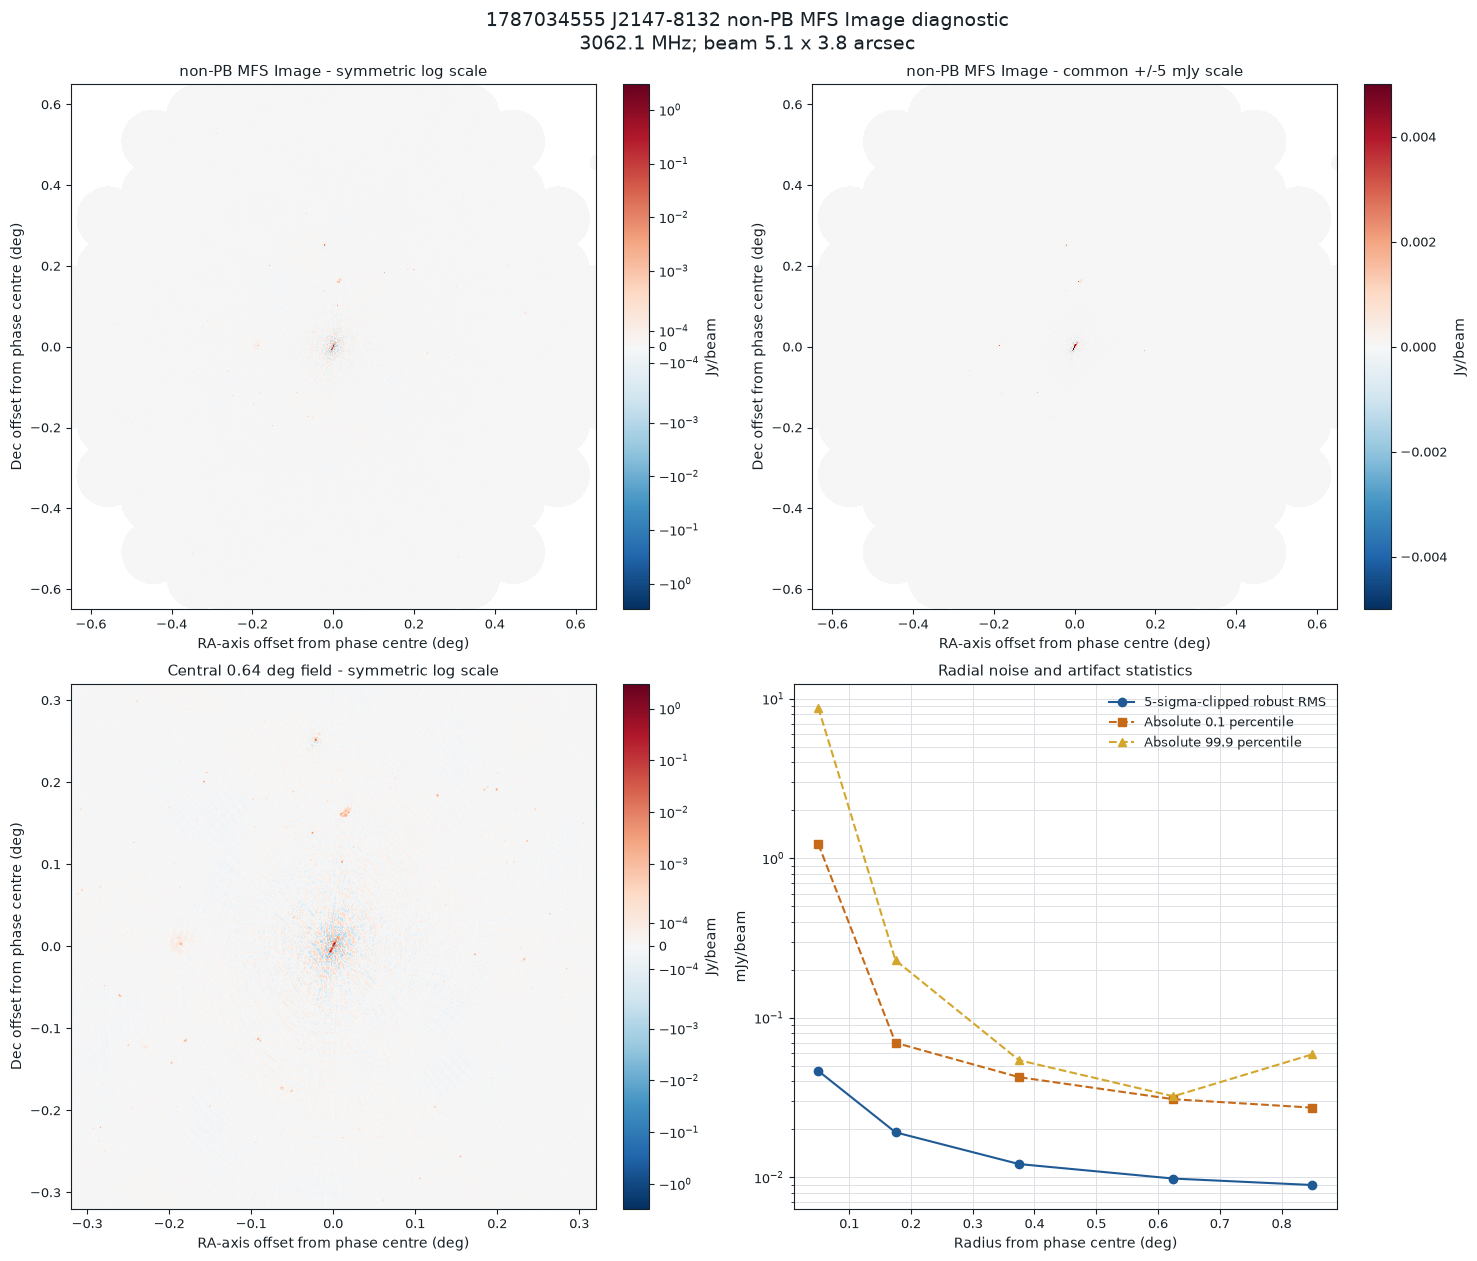

,outer_rms_mjy_beam,central_annulus_rms_mjy_beam,central_to_outer_rms,sampled_min_mjy_beam,sampled_max_jy_beam,header_DATAMIN_jy_beam,header_DATAMAX_jy_beam
0,0.01213,0.04616,3.805,-4.415,0.7804,-197.3,226.7


Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_01_combined_plane_diagnostic.png


In [11]:
## Live code
intensity_sample = sampled_plane(0)
finite_intensity = intensity_sample[np.isfinite(intensity_sample)]
combined_median, combined_background_rms, combined_background_kept = robust_location_scale(
    intensity_sample[background_annulus_mask]
)
central_median, combined_central_rms, combined_central_kept = robust_location_scale(
    intensity_sample[central_annulus_mask]
)

annulus_edges = np.asarray(RADIAL_PROFILE_EDGES_DEG, dtype=float)
radial_rows = []
for lower_radius, upper_radius in zip(annulus_edges[:-1], annulus_edges[1:]):
    mask = (
        (sample_radius_deg >= lower_radius)
        & (sample_radius_deg < upper_radius)
        & np.isfinite(intensity_sample)
    )
    median, rms, kept = robust_location_scale(intensity_sample[mask])
    values = intensity_sample[mask]
    p0_1, p99_9 = np.percentile(values, [0.1, 99.9])
    radial_rows.append({
        "radius_mid_deg": 0.5 * (lower_radius + upper_radius),
        "robust_rms_mjy_beam": 1e3 * rms,
        "abs_p0_1_mjy_beam": 1e3 * abs(p0_1),
        "abs_p99_9_mjy_beam": 1e3 * abs(p99_9),
        "samples_kept": kept,
    })
radial_profile = pd.DataFrame(radial_rows)

central_crop = np.asarray(
    INTENSITY_PLANE[
        crop_y0:crop_y1:CENTRAL_CROP_STRIDE,
        crop_x0:crop_x1:CENTRAL_CROP_STRIDE,
    ]
)

fig, axes = plt.subplots(2, 2, figsize=(14.5, 12.5), constrained_layout=True)

image = axes[0, 0].imshow(
    intensity_sample,
    origin="lower",
    extent=full_extent_deg,
    cmap="RdBu_r",
    norm=SymLogNorm(linthresh=3e-4, linscale=0.8, vmin=-3, vmax=3),
    interpolation="nearest",
)
axes[0, 0].set_title("non-PB MFS Image - symmetric log scale")
axes[0, 0].set_xlabel("RA-axis offset from phase centre (deg)")
axes[0, 0].set_ylabel("Dec offset from phase centre (deg)")
fig.colorbar(image, ax=axes[0, 0], label="Jy/beam")

image = axes[0, 1].imshow(
    intensity_sample,
    origin="lower",
    extent=full_extent_deg,
    cmap="RdBu_r",
    vmin=-COMMON_DISPLAY_LIMIT_MJY / 1e3,
    vmax=COMMON_DISPLAY_LIMIT_MJY / 1e3,
    interpolation="nearest",
)
axes[0, 1].set_title(f"non-PB MFS Image - common +/-{COMMON_DISPLAY_LIMIT_MJY:g} mJy scale")
axes[0, 1].set_xlabel("RA-axis offset from phase centre (deg)")
axes[0, 1].set_ylabel("Dec offset from phase centre (deg)")
fig.colorbar(image, ax=axes[0, 1], label="Jy/beam")

image = axes[1, 0].imshow(
    central_crop,
    origin="lower",
    extent=central_extent_deg,
    cmap="RdBu_r",
    norm=SymLogNorm(linthresh=2e-4, linscale=0.8, vmin=-3, vmax=3),
    interpolation="nearest",
)
axes[1, 0].set_title(
    f"Central {2 * CENTRAL_CROP_DEG:g} deg field - symmetric log scale"
)
axes[1, 0].set_xlabel("RA-axis offset from phase centre (deg)")
axes[1, 0].set_ylabel("Dec offset from phase centre (deg)")
fig.colorbar(image, ax=axes[1, 0], label="Jy/beam")

axes[1, 1].plot(
    radial_profile["radius_mid_deg"],
    radial_profile["robust_rms_mjy_beam"],
    "o-", color=BLUE, label=f"{ROBUST_CLIP_SIGMA:g}-sigma-clipped robust RMS",
)
axes[1, 1].plot(
    radial_profile["radius_mid_deg"],
    radial_profile["abs_p0_1_mjy_beam"],
    "s--", color=ORANGE, label="Absolute 0.1 percentile",
)
axes[1, 1].plot(
    radial_profile["radius_mid_deg"],
    radial_profile["abs_p99_9_mjy_beam"],
    "^--", color=GOLD, label="Absolute 99.9 percentile",
)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Radial noise and artifact statistics")
axes[1, 1].set_xlabel("Radius from phase centre (deg)")
axes[1, 1].set_ylabel("mJy/beam")
axes[1, 1].grid(True, which="both", color=GRID, linewidth=0.7)
axes[1, 1].legend()

fig.suptitle(
    f"{CBID} {TARGET_NAME} non-PB MFS Image diagnostic\n"
    f"{REFERENCE_FREQUENCY_HZ / 1e6:.1f} MHz; "
    f"beam {primary_header['BMAJ'] * 3600:.1f} x "
    f"{primary_header['BMIN'] * 3600:.1f} arcsec",
    fontsize=1.4 * FIGURE_FONT_SIZE,
)
figure_path = output_path("01_combined_plane_diagnostic.png")
fig.savefig(figure_path, dpi=FIGURE_DPI)
plt.show()

actual_min = float(np.nanmin(finite_intensity))
actual_max = float(np.nanmax(finite_intensity))
combined_summary = pd.DataFrame([{
    "outer_rms_mjy_beam": 1e3 * combined_background_rms,
    "central_annulus_rms_mjy_beam": 1e3 * combined_central_rms,
    "central_to_outer_rms": combined_central_rms / combined_background_rms,
    "sampled_min_mjy_beam": 1e3 * actual_min,
    "sampled_max_jy_beam": actual_max,
    "header_DATAMIN_jy_beam": float(primary_header["DATAMIN"]),
    "header_DATAMAX_jy_beam": float(primary_header["DATAMAX"]),
}])
display(combined_summary.style.format("{:.4g}"))
print(f"Saved: {figure_path}")

Interpret the radial profile together
with the two image scales. A central-to-outer RMS ratio above unity indicates
source-associated residual structure. Header `DATAMIN`/`DATAMAX` values are shown
only as a provenance check; display limits and statistics come from the pixels.

### 6. Measure every independent subband

The table is the core frequency-dependent QA result. Peak flux and position are measured inside 0.03 deg of the phase centre. Noise and artifact statistics use the two annuli defined above.

In [12]:
## Live code
core_radius_pixels = int(np.ceil(PEAK_SEARCH_RADIUS_DEG / PIXEL_SCALE_DEG))
core_x0 = max(0, int(round(CENTER_X)) - core_radius_pixels)
core_x1 = min(NX, int(round(CENTER_X)) + core_radius_pixels + 1)
core_y0 = max(0, int(round(CENTER_Y)) - core_radius_pixels)
core_y1 = min(NY, int(round(CENTER_Y)) + core_radius_pixels + 1)
core_y_grid, core_x_grid = np.ogrid[core_y0:core_y1, core_x0:core_x1]
core_radius_deg = np.sqrt(
    ((core_x_grid - CENTER_X) * PIXEL_SCALE_DEG) ** 2
    + ((core_y_grid - CENTER_Y) * PIXEL_SCALE_DEG) ** 2
)
core_mask = core_radius_deg < PEAK_SEARCH_RADIUS_DEG

intensity_core = np.asarray(INTENSITY_PLANE[core_y0:core_y1, core_x0:core_x1])
intensity_peak_flat = int(np.argmax(
    np.where(core_mask & np.isfinite(intensity_core), intensity_core, -np.inf)
))
intensity_peak_local_y, intensity_peak_local_x = np.unravel_index(
    intensity_peak_flat, intensity_core.shape
)
intensity_peak_y = core_y0 + intensity_peak_local_y
intensity_peak_x = core_x0 + intensity_peak_local_x
alpha_at_intensity_peak = float(ALPHA_PLANE[intensity_peak_y, intensity_peak_x])

metric_rows = []
central_pattern_vectors = []
for subband_zero_index, frequency_hz in enumerate(SUBBAND_FREQUENCIES_HZ):
    plane_index = NTERM + subband_zero_index
    plane = image_planes[plane_index]
    sampled = sampled_plane(plane_index)

    background_median, background_rms, background_kept = robust_location_scale(
        sampled[background_annulus_mask]
    )
    central_median, central_rms, central_kept = robust_location_scale(
        sampled[central_annulus_mask]
    )

    central_values = sampled[central_annulus_mask & np.isfinite(sampled)]
    central_p0_1, central_p99_9 = np.percentile(central_values, [0.1, 99.9])
    field_values = sampled[science_field_mask & np.isfinite(sampled)]

    core_values = np.asarray(plane[core_y0:core_y1, core_x0:core_x1])
    valid_core = np.where(core_mask & np.isfinite(core_values), core_values, -np.inf)
    peak_flat = int(np.argmax(valid_core))
    peak_local_y, peak_local_x = np.unravel_index(peak_flat, valid_core.shape)
    peak_y = core_y0 + peak_local_y
    peak_x = core_x0 + peak_local_x
    peak_value = float(plane[peak_y, peak_x])
    peak_shift_arcsec = (
        np.hypot(peak_x - intensity_peak_x, peak_y - intensity_peak_y)
        * PIXEL_SCALE_DEG * 3600.0
    )

    pattern_vector = np.asarray(sampled[central_annulus_mask], dtype=np.float64)
    central_pattern_vectors.append(
        np.clip(pattern_vector, -PATTERN_CLIP_JY, PATTERN_CLIP_JY)
    )

    metric_rows.append({
        "subband": subband_zero_index + 1,
        "plane": plane_index,
        "frequency_mhz": frequency_hz / 1e6,
        "peak_jy_beam": peak_value,
        "peak_shift_arcsec": peak_shift_arcsec,
        "outer_rms_mjy_beam": 1e3 * background_rms,
        "central_rms_mjy_beam": 1e3 * central_rms,
        "central_to_outer_rms": central_rms / background_rms,
        "central_p0_1_mjy_beam": 1e3 * central_p0_1,
        "central_p99_9_mjy_beam": 1e3 * central_p99_9,
        "field_min_mjy_beam": 1e3 * np.min(field_values),
        "field_max_jy_beam": np.max(field_values),
        "dynamic_range": peak_value / background_rms,
        "outer_samples_kept": background_kept,
        "central_samples_kept": central_kept,
    })

subband_metrics = pd.DataFrame(metric_rows)
subband_metrics["assessment"] = np.where(
    subband_metrics["outer_rms_mjy_beam"] >= SEVERE_RMS_THRESHOLD_MJY,
    "severe corruption",
    "lower-noise subband",
)
best_subband_rms = subband_metrics["outer_rms_mjy_beam"].min()
subband_metrics["rms_vs_best"] = (
    subband_metrics["outer_rms_mjy_beam"] / best_subband_rms
)

lower_noise_mask = subband_metrics["assessment"].eq("lower-noise subband").to_numpy()
log_frequency_ratio = np.log(SUBBAND_FREQUENCIES_HZ / REFERENCE_FREQUENCY_HZ)
peak_fluxes = subband_metrics["peak_jy_beam"].to_numpy()
spectral_fit_mask = (
    lower_noise_mask & np.isfinite(peak_fluxes) & (peak_fluxes > 0)
)
if spectral_fit_mask.sum() >= 2:
    lower_noise_fit = np.polyfit(
        log_frequency_ratio[spectral_fit_mask],
        np.log(peak_fluxes[spectral_fit_mask]),
        deg=1,
    )
    lower_noise_alpha = float(lower_noise_fit[0])
    fitted_peak_model = np.exp(np.polyval(lower_noise_fit, log_frequency_ratio))
else:
    lower_noise_fit = None
    lower_noise_alpha = np.nan
    fitted_peak_model = np.full(NSPEC, np.nan)
subband_metrics["lower_noise_powerlaw_model_jy_beam"] = fitted_peak_model
subband_metrics["peak_residual_percent"] = np.where(
    np.isfinite(fitted_peak_model),
    100.0 * (peak_fluxes / fitted_peak_model - 1.0),
    np.nan,
)

pattern_correlation = np.corrcoef(np.vstack(central_pattern_vectors))

display_columns = [
    "subband", "frequency_mhz", "outer_rms_mjy_beam",
    "central_rms_mjy_beam", "rms_vs_best", "peak_jy_beam",
    "peak_residual_percent", "peak_shift_arcsec", "assessment",
]
display(
    subband_metrics[display_columns].style
    .format({
        "frequency_mhz": "{:.1f}",
        "outer_rms_mjy_beam": "{:.3f}",
        "central_rms_mjy_beam": "{:.3f}",
        "rms_vs_best": "{:.1f}x",
        "peak_jy_beam": "{:.3f}",
        "peak_residual_percent": "{:+.1f}%",
        "peak_shift_arcsec": "{:.2f}",
    })
)

metrics_path = output_path("subband_metrics.csv")
subband_metrics.to_csv(metrics_path, index=False)
print(
    f"Lower-noise subband spectral index: {lower_noise_alpha:.3f}"
    if np.isfinite(lower_noise_alpha)
    else "Lower-noise subband spectral index: unavailable (<2 valid bands)"
)
print(f"MFImage alpha at non-PB MFS Image peak: {alpha_at_intensity_peak:.3f}")
print(
    "Severely corrupted subbands: "
    + ", ".join(
        f"{value:.1f} MHz"
        for value in subband_metrics.loc[
            subband_metrics["assessment"].eq("severe corruption"),
            "frequency_mhz",
        ]
    )
)
print(f"Saved: {metrics_path}")

,subband,frequency_mhz,outer_rms_mjy_beam,central_rms_mjy_beam,rms_vs_best,peak_jy_beam,peak_residual_percent,peak_shift_arcsec,assessment
0,1,2707.3,0.070,0.445,2.5x,0.840,+2.4%,0.00,lower-noise subband
1,2,2777.1,0.031,0.171,1.1x,0.821,-0.2%,0.00,lower-noise subband
2,3,2882.7,0.028,0.165,1.0x,0.816,-1.1%,0.00,lower-noise subband
3,4,2991.4,0.029,0.170,1.0x,0.819,-1.1%,0.00,lower-noise subband
4,5,3106.5,0.038,0.187,1.4x,0.813,-2.2%,0.00,lower-noise subband
5,6,3217.3,0.032,0.171,1.1x,0.834,+0.0%,0.00,lower-noise subband
6,7,3343.8,0.033,0.169,1.2x,0.853,+1.9%,0.00,lower-noise subband
7,8,3426.7,0.088,0.255,3.1x,0.842,+0.4%,0.00,lower-noise subband


Lower-noise subband spectral index: 0.094
MFImage alpha at non-PB MFS Image peak: 0.145
Severely corrupted subbands: 
Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_subband_metrics.csv


The assessment below is generated from the current observation. A band is
classified as severe only against the configured image-domain threshold; inspect
the common-scale and sigma-scale matrices before assigning an instrumental cause.

In [13]:
## Live code
severe_rows = subband_metrics[
    subband_metrics["assessment"].eq("severe corruption")
]
lower_noise_rows = subband_metrics[
    subband_metrics["assessment"].eq("lower-noise subband")
]
severe_count = len(severe_rows)
severe_frequency_text = (
    ", ".join(f"{value:.1f}" for value in severe_rows["frequency_mhz"])
    if severe_count else "none"
)
spectral_index_text = (
    f"{lower_noise_alpha:.3f}"
    if np.isfinite(lower_noise_alpha)
    else "not available"
)

observation_summary_markdown = f"""#### Observation-specific subband summary

- **CBID:** {CBID}
- **Subbands above {SEVERE_RMS_THRESHOLD_MJY:g} mJy/beam outer RMS:**
  {severe_count} of {NSPEC}
- **Affected effective frequencies:** {severe_frequency_text} MHz
- **Lower-noise outer RMS range:**
  {lower_noise_rows['outer_rms_mjy_beam'].min():.3g} to
  {lower_noise_rows['outer_rms_mjy_beam'].max():.3g} mJy/beam
  {'' if len(lower_noise_rows) else '(no lower-noise bands)'}
- **Severe-band outer RMS range:**
  {severe_rows['outer_rms_mjy_beam'].min():.3g} to
  {severe_rows['outer_rms_mjy_beam'].max():.3g} mJy/beam
  {'' if severe_count else '(no severe bands)'}
- **Spectral index from valid lower-noise peak measurements:** {spectral_index_text}
- **MFImage alpha at the non-PB MFS Image peak:** {alpha_at_intensity_peak:.3f}
"""
display(Markdown(observation_summary_markdown))

#### Observation-specific subband summary

- **CBID:** 1787034555
- **Subbands above 10 mJy/beam outer RMS:**
  0 of 8
- **Affected effective frequencies:** none MHz
- **Lower-noise outer RMS range:**
  0.0283 to
  0.0876 mJy/beam
  
- **Severe-band outer RMS range:**
  nan to
  nan mJy/beam
  (no severe bands)
- **Spectral index from valid lower-noise peak measurements:** 0.094
- **MFImage alpha at the non-PB MFS Image peak:** 0.145


### 7. Subband image matrix on a common physical scale

Every panel uses the same +/-5 mJy/beam scale. This is intentionally unforgiving: saturation in a panel is itself evidence that its frequency plane is not comparable with the lower-noise planes.

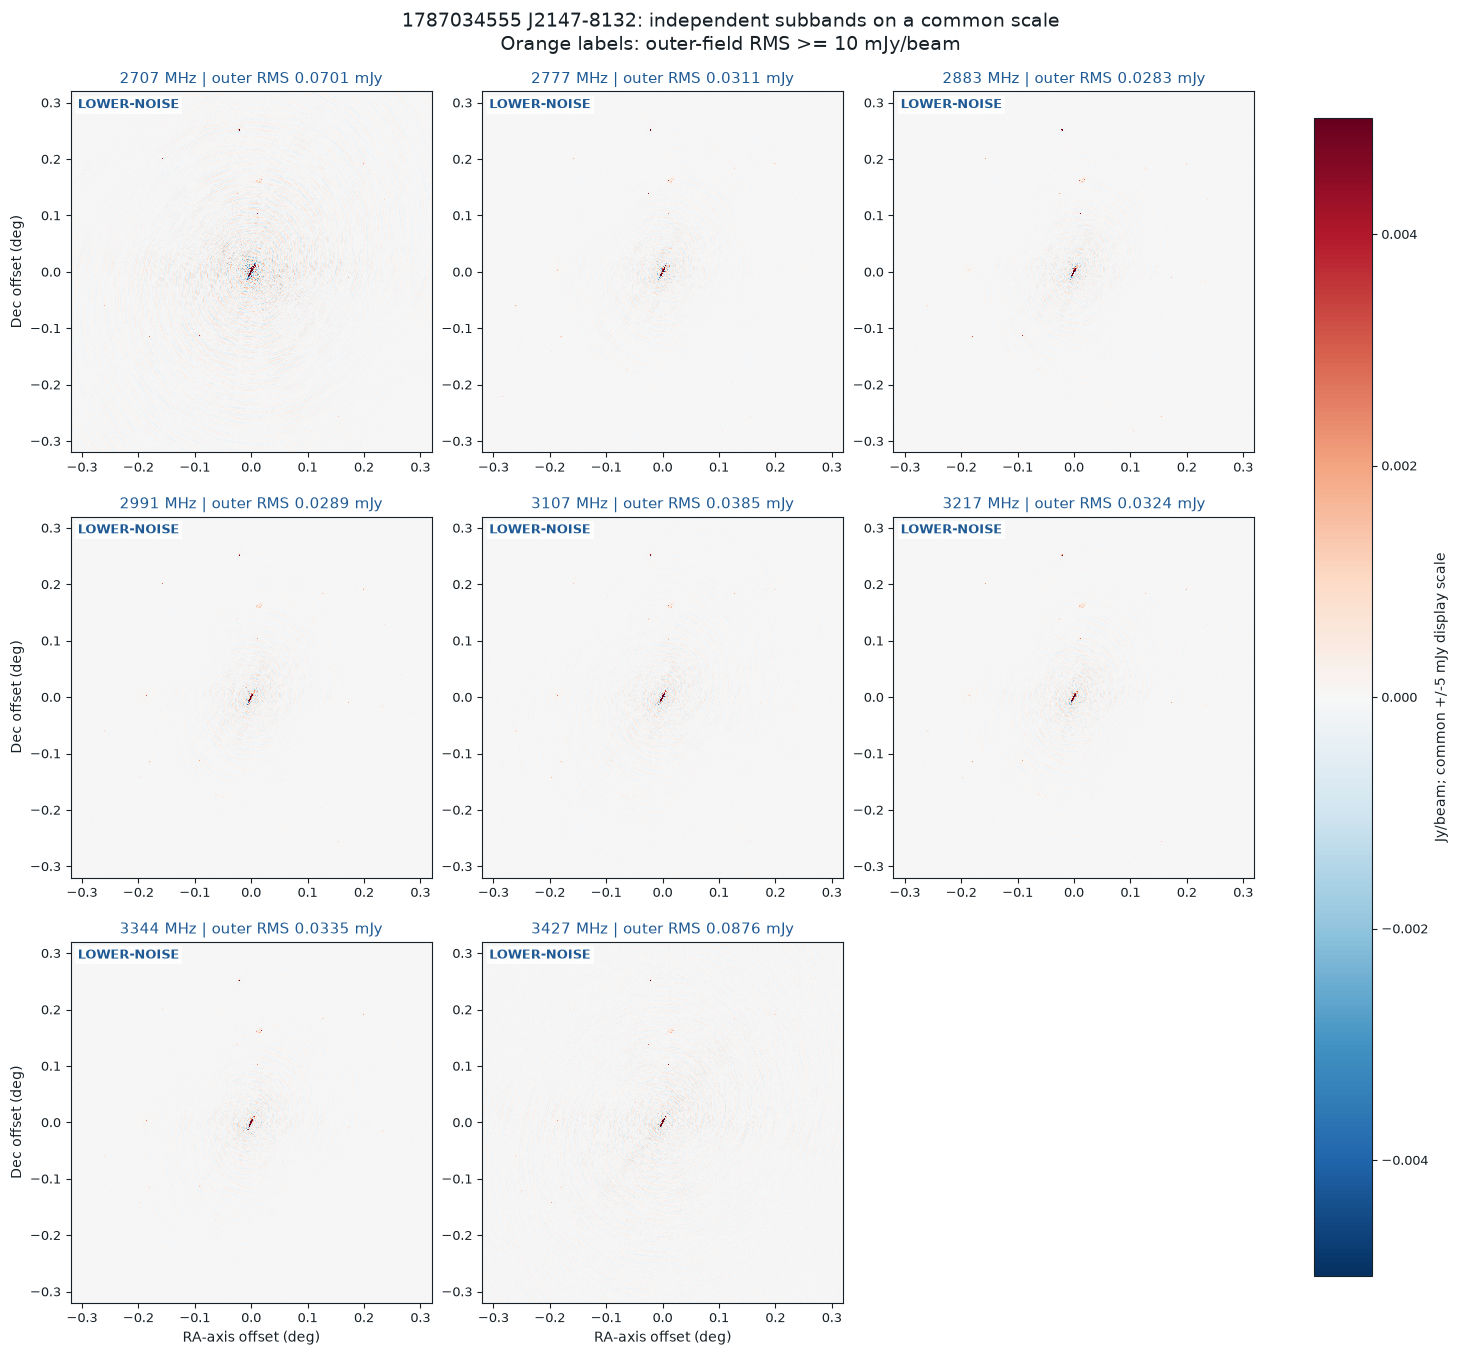

Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_02_subband_common_scale.png


In [14]:
## Live code
SUBBAND_COLUMNS = min(MAX_SUBBAND_COLUMNS, NSPEC)
SUBBAND_ROWS = int(np.ceil(NSPEC / SUBBAND_COLUMNS))
fig, axes = plt.subplots(
    SUBBAND_ROWS, SUBBAND_COLUMNS,
    figsize=(14.5, 4.5 * SUBBAND_ROWS),
    constrained_layout=True, squeeze=False,
)
common_image = None
for row_index, (axis, metric) in enumerate(
    zip(axes.ravel(), subband_metrics.itertuples(index=False))
):
    plane_crop = np.asarray(
        image_planes[
            int(metric.plane),
            crop_y0:crop_y1:CENTRAL_CROP_STRIDE,
            crop_x0:crop_x1:CENTRAL_CROP_STRIDE,
        ]
    )
    common_image = axis.imshow(
        plane_crop,
        origin="lower",
        extent=central_extent_deg,
        cmap="RdBu_r",
        vmin=-COMMON_DISPLAY_LIMIT_MJY / 1e3,
        vmax=COMMON_DISPLAY_LIMIT_MJY / 1e3,
        interpolation="nearest",
    )
    title_color = ORANGE if metric.assessment == "severe corruption" else BLUE
    axis.set_title(
        f"{metric.frequency_mhz:.0f} MHz | outer RMS {metric.outer_rms_mjy_beam:.3g} mJy",
        color=title_color,
    )
    add_panel_label(
        axis,
        "SEVERE" if metric.assessment == "severe corruption" else "LOWER-NOISE",
        color=title_color,
    )
    if row_index // SUBBAND_COLUMNS == SUBBAND_ROWS - 1:
        axis.set_xlabel("RA-axis offset (deg)")
    if row_index % SUBBAND_COLUMNS == 0:
        axis.set_ylabel("Dec offset (deg)")

for axis in axes.ravel()[NSPEC:]:
    axis.set_visible(False)

colorbar = fig.colorbar(
    common_image,
    ax=axes.ravel().tolist(),
    shrink=0.92,
    label=f"Jy/beam; common +/-{COMMON_DISPLAY_LIMIT_MJY:g} mJy display scale",
)
fig.suptitle(
    f"{CBID} {TARGET_NAME}: independent subbands on a common scale\n"
    f"Orange labels: outer-field RMS >= {SEVERE_RMS_THRESHOLD_MJY:g} mJy/beam",
    fontsize=1.4 * FIGURE_FONT_SIZE,
)
figure_path = output_path("02_subband_common_scale.png")
fig.savefig(figure_path, dpi=FIGURE_DPI)
plt.show()
print(f"Saved: {figure_path}")

The common physical scale tests
whether subbands are directly comparable. Saturation confined to separated frequency
intervals is evidence for frequency-localized corruption; a smooth radial or
band-edge trend would require a different interpretation.

### 8. Subband morphology in local-noise units

The same images are divided by their own outer-field robust RMS and clipped at +/-8 sigma. This view shows morphology rather than absolute amplitude; it must be read together with the common-scale matrix.

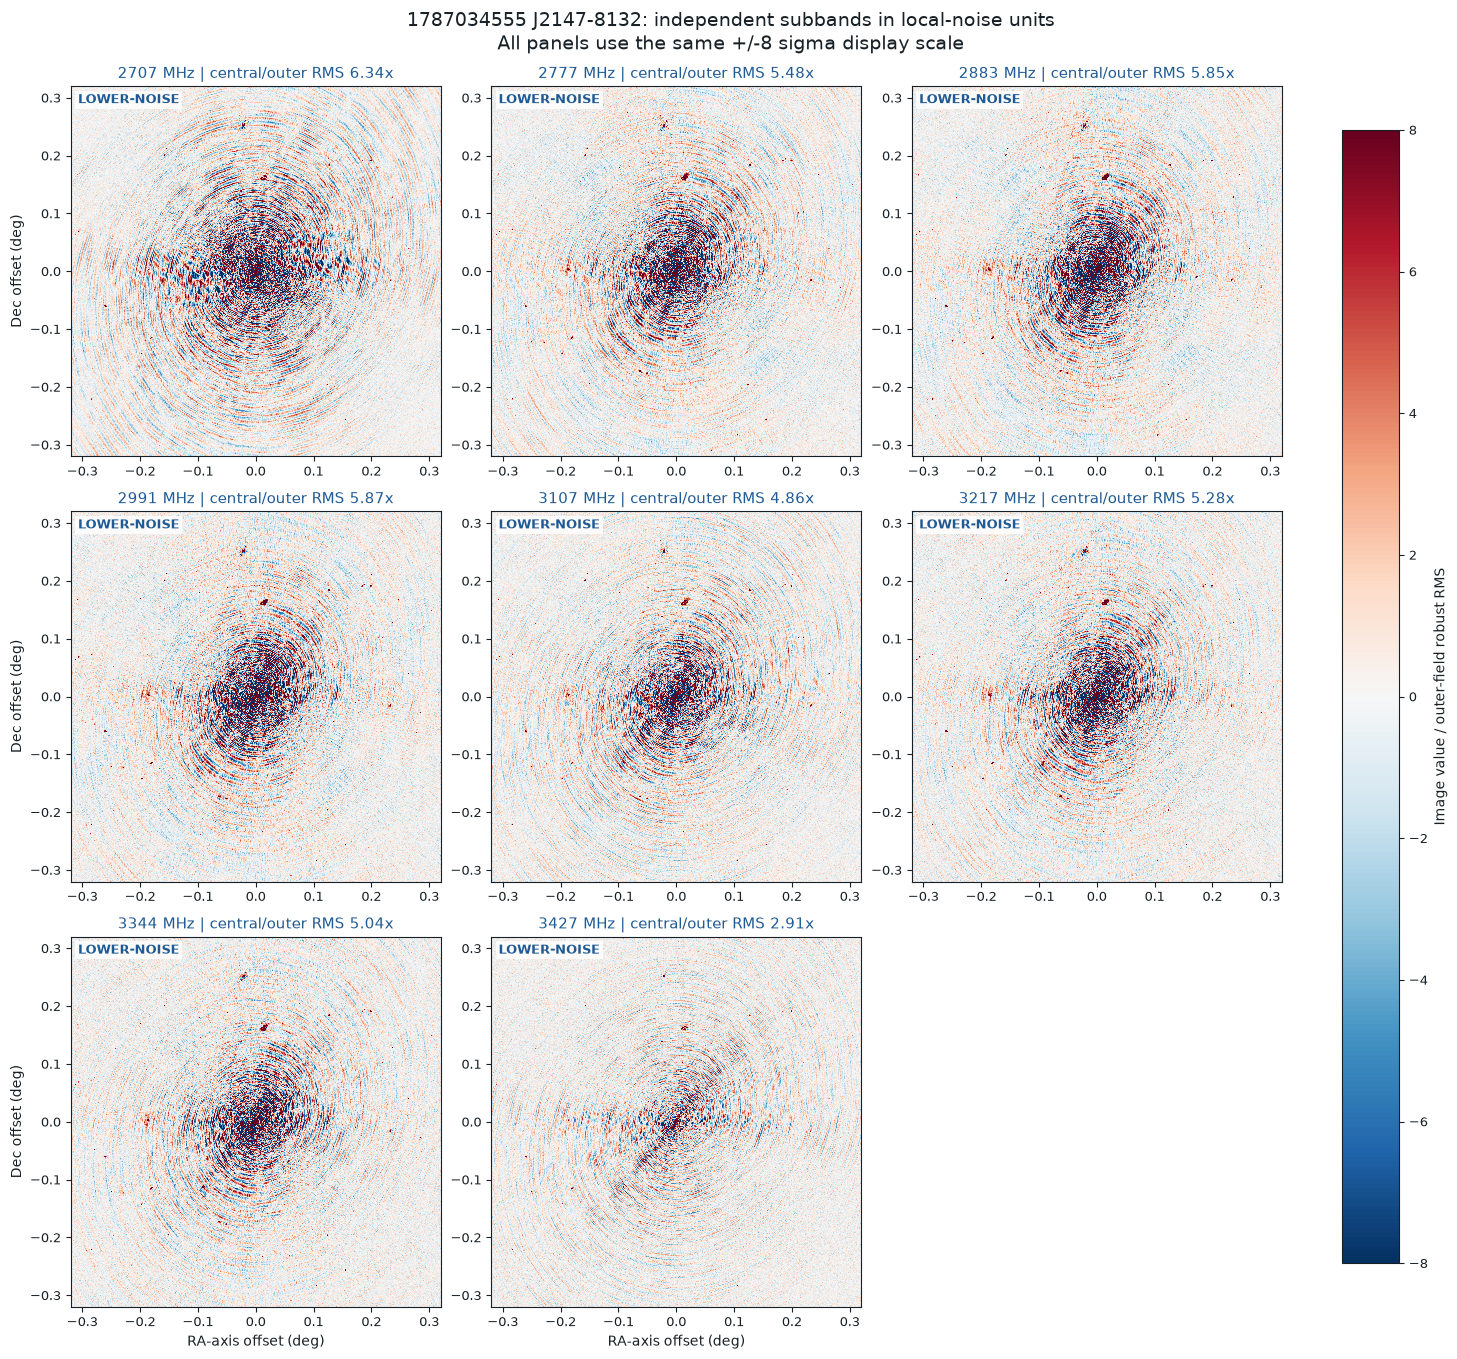

Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_03_subband_sigma_scale.png


In [15]:
## Live code
fig, axes = plt.subplots(
    SUBBAND_ROWS, SUBBAND_COLUMNS,
    figsize=(14.5, 4.5 * SUBBAND_ROWS),
    constrained_layout=True, squeeze=False,
)
sigma_image = None
for row_index, (axis, metric) in enumerate(
    zip(axes.ravel(), subband_metrics.itertuples(index=False))
):
    plane_crop_mjy = 1e3 * np.asarray(
        image_planes[
            int(metric.plane),
            crop_y0:crop_y1:CENTRAL_CROP_STRIDE,
            crop_x0:crop_x1:CENTRAL_CROP_STRIDE,
        ]
    )
    significance_crop = plane_crop_mjy / metric.outer_rms_mjy_beam
    sigma_image = axis.imshow(
        significance_crop,
        origin="lower",
        extent=central_extent_deg,
        cmap="RdBu_r",
        vmin=-SIGMA_DISPLAY_LIMIT,
        vmax=SIGMA_DISPLAY_LIMIT,
        interpolation="nearest",
    )
    title_color = ORANGE if metric.assessment == "severe corruption" else BLUE
    axis.set_title(
        f"{metric.frequency_mhz:.0f} MHz | central/outer RMS "
        f"{metric.central_to_outer_rms:.2f}x",
        color=title_color,
    )
    add_panel_label(
        axis,
        "SEVERE" if metric.assessment == "severe corruption" else "LOWER-NOISE",
        color=title_color,
    )
    if row_index // SUBBAND_COLUMNS == SUBBAND_ROWS - 1:
        axis.set_xlabel("RA-axis offset (deg)")
    if row_index % SUBBAND_COLUMNS == 0:
        axis.set_ylabel("Dec offset (deg)")

for axis in axes.ravel()[NSPEC:]:
    axis.set_visible(False)

fig.colorbar(
    sigma_image,
    ax=axes.ravel().tolist(),
    shrink=0.92,
    label="Image value / outer-field robust RMS",
)
fig.suptitle(
    f"{CBID} {TARGET_NAME}: independent subbands in local-noise units\n"
    f"All panels use the same +/-{SIGMA_DISPLAY_LIMIT:g} sigma display scale",
    fontsize=1.4 * FIGURE_FONT_SIZE,
)
figure_path = output_path("03_subband_sigma_scale.png")
fig.savefig(figure_path, dpi=FIGURE_DPI)
plt.show()
print(f"Saved: {figure_path}")

### 9. Frequency trends, source spectrum and morphology agreement

The left-hand plots measure absolute image quality. The peak-spectrum fit uses only the lower-noise subbands; this avoids allowing known corrupted planes to define the expected spectrum. The correlation matrix compares clipped central-annulus patterns, where a stable PSF residual would normally retain stronger adjacent-band similarity.

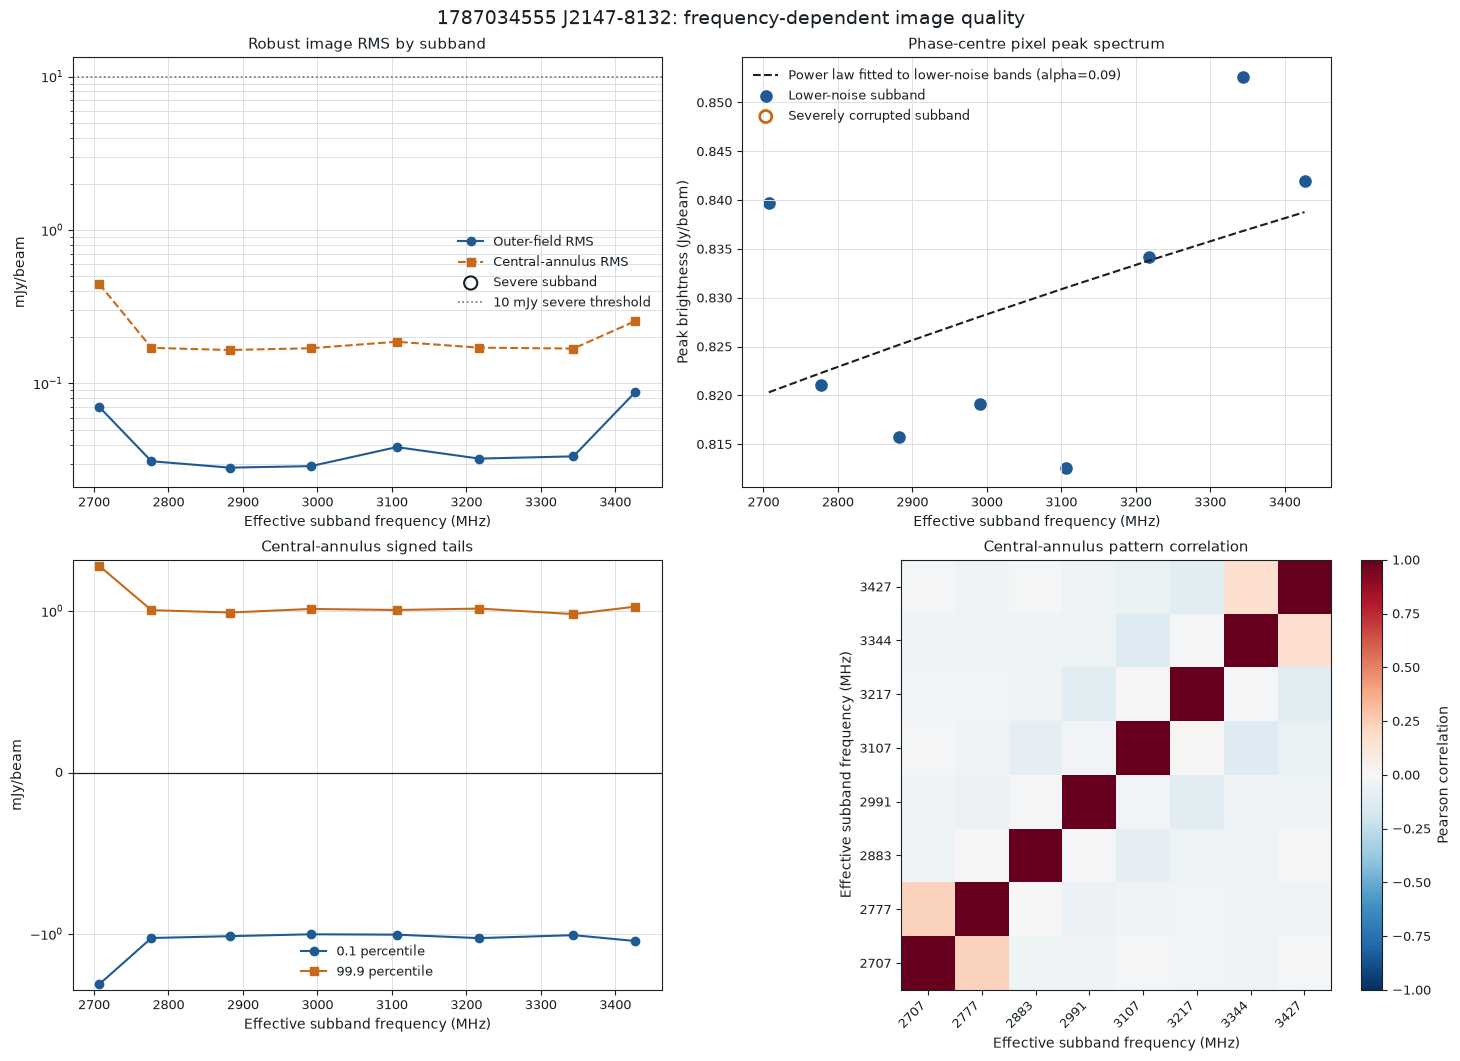

Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_04_frequency_metrics.png


In [23]:
## Live code
frequency_mhz = subband_metrics["frequency_mhz"].to_numpy()
severe_mask = subband_metrics["assessment"].eq("severe corruption").to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14.5, 10.5), constrained_layout=True)

axes[0, 0].plot(
    frequency_mhz,
    subband_metrics["outer_rms_mjy_beam"],
    "o-", color=BLUE, label="Outer-field RMS",
)
axes[0, 0].plot(
    frequency_mhz,
    subband_metrics["central_rms_mjy_beam"],
    "s--", color=ORANGE, label="Central-annulus RMS",
)
axes[0, 0].scatter(
    frequency_mhz[severe_mask],
    subband_metrics.loc[severe_mask, "outer_rms_mjy_beam"],
    s=90, facecolors="none", edgecolors=INK, linewidths=1.5,
    label="Severe subband",
)
axes[0, 0].axhline(
    SEVERE_RMS_THRESHOLD_MJY,
    color=MUTED, linestyle=":", linewidth=1.2,
    label=f"{SEVERE_RMS_THRESHOLD_MJY:g} mJy severe threshold",
)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Robust image RMS by subband")
axes[0, 0].set_xlabel("Effective subband frequency (MHz)")
axes[0, 0].set_ylabel("mJy/beam")
axes[0, 0].grid(True, which="both", color=GRID, linewidth=0.7)
axes[0, 0].legend()

axes[0, 1].plot(
    frequency_mhz,
    subband_metrics["lower_noise_powerlaw_model_jy_beam"],
    color=INK, linestyle="--",
    label=(
        f"Power law fitted to lower-noise bands (alpha={lower_noise_alpha:.2f})"
        if np.isfinite(lower_noise_alpha)
        else "Power-law fit unavailable"
    ),
)
axes[0, 1].scatter(
    frequency_mhz[~severe_mask],
    subband_metrics.loc[~severe_mask, "peak_jy_beam"],
    s=65, color=BLUE, label="Lower-noise subband",
)
axes[0, 1].scatter(
    frequency_mhz[severe_mask],
    subband_metrics.loc[severe_mask, "peak_jy_beam"],
    s=75, facecolors="none", edgecolors=ORANGE, linewidths=2,
    label="Severely corrupted subband",
)
axes[0, 1].set_title("Phase-centre pixel peak spectrum")
axes[0, 1].set_xlabel("Effective subband frequency (MHz)")
axes[0, 1].set_ylabel("Peak brightness (Jy/beam)")
axes[0, 1].grid(True, color=GRID, linewidth=0.7)
axes[0, 1].legend()

axes[1, 0].plot(
    frequency_mhz,
    subband_metrics["central_p0_1_mjy_beam"],
    "o-", color=BLUE, label="0.1 percentile",
)
axes[1, 0].plot(
    frequency_mhz,
    subband_metrics["central_p99_9_mjy_beam"],
    "s-", color=ORANGE, label="99.9 percentile",
)
axes[1, 0].axhline(0, color=INK, linewidth=0.9)
axes[1, 0].set_yscale("symlog", linthresh=1.0)
axes[1, 0].set_title("Central-annulus signed tails")
axes[1, 0].set_xlabel("Effective subband frequency (MHz)")
axes[1, 0].set_ylabel("mJy/beam")
axes[1, 0].grid(True, which="both", color=GRID, linewidth=0.7)
axes[1, 0].legend()

correlation_image = axes[1, 1].imshow(
    pattern_correlation,
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
)
tick_labels = [f"{value:.0f}" for value in frequency_mhz]
axes[1, 1].set_xticks(np.arange(NSPEC), tick_labels, rotation=45, ha="right")
axes[1, 1].set_yticks(np.arange(NSPEC), tick_labels)
axes[1, 1].set_title("Central-annulus pattern correlation")
axes[1, 1].set_xlabel("Effective subband frequency (MHz)")
axes[1, 1].set_ylabel("Effective subband frequency (MHz)")
fig.colorbar(correlation_image, ax=axes[1, 1], label="Pearson correlation")

fig.suptitle(
    f"{CBID} {TARGET_NAME}: frequency-dependent image quality",
    fontsize=1.4 * FIGURE_FONT_SIZE,
)
figure_path = output_path("04_frequency_metrics.png")
fig.savefig(figure_path, dpi=FIGURE_DPI)
plt.show()
print(f"Saved: {figure_path}")

Read the four panels together. Inflated RMS and signed tails identify absolute
degradation, while peak-spectrum residuals test source consistency.

**Central-annulus pattern correlation:** each square compares the clipped pixel
pattern in the central annulus between two subbands using Pearson correlation.
`+1` means the same bright/dark structure, `0` means no clear linear similarity,
and `-1` means the pattern is reversed. The diagonal is always `+1`. Strong
off-diagonal blocks indicate structure that persists across frequency; weak or
negative values indicate changing, frequency-dependent morphology. Correlation
measures shape, not amplitude, so read it together with the RMS panels.

### 10. Spectral-index plane quality

MFImage explicitly permits a default spectral index where an extra fitted term is not statistically justified. Therefore, zeros in plane 1 are not measurements of a flat spectrum. The map below shows alpha only where the non-PB MFS Image brightness exceeds 10 times the outer-field RMS and alpha is non-zero.

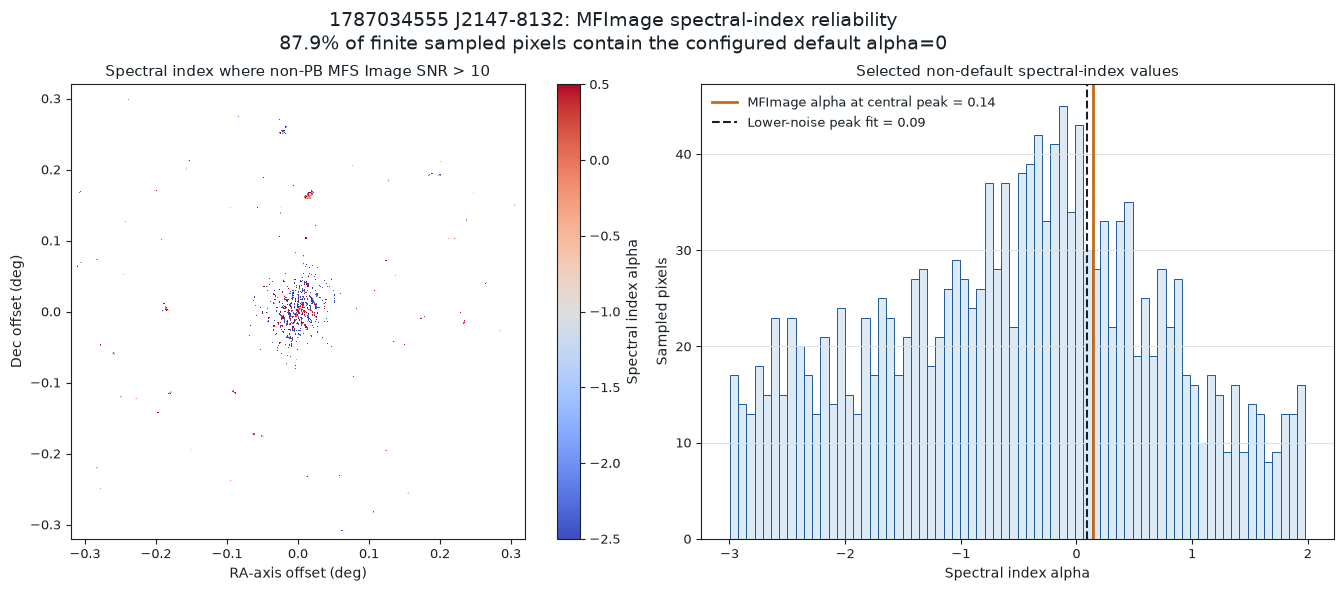

,finite_sampled_pixels,default_zero_fraction,selected_nondefault_pixels,selected_fraction_of_finite,alpha_at_central_peak,alpha_from_lower_noise_peak_spectrum
0,3316256,87.91%,4242,0.128%,0.145,0.094


Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_05_spectral_index_quality.png


In [17]:
## Live code
alpha_sample = sampled_plane(1)
finite_alpha_mask = np.isfinite(alpha_sample)
default_alpha_fraction = float(np.mean(alpha_sample[finite_alpha_mask] == 0.0))

alpha_measurement_mask = (
    finite_alpha_mask
    & np.isfinite(intensity_sample)
    & (intensity_sample > ALPHA_SNR_MIN * combined_background_rms)
    & (alpha_sample != 0.0)
    & science_field_mask
)
alpha_values = alpha_sample[alpha_measurement_mask]

masked_alpha = np.where(alpha_measurement_mask, alpha_sample, np.nan)
alpha_crop = masked_alpha[
    int(crop_y0 / DISPLAY_STRIDE):int(crop_y1 / DISPLAY_STRIDE),
    int(crop_x0 / DISPLAY_STRIDE):int(crop_x1 / DISPLAY_STRIDE),
]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), constrained_layout=True)

alpha_image = axes[0].imshow(
    alpha_crop,
    origin="lower",
    extent=central_extent_deg,
    cmap="coolwarm",
    vmin=ALPHA_MAP_MIN,
    vmax=ALPHA_MAP_MAX,
    interpolation="nearest",
)
axes[0].set_title(
    f"Spectral index where non-PB MFS Image SNR > {ALPHA_SNR_MIN:g}"
)
axes[0].set_xlabel("RA-axis offset (deg)")
axes[0].set_ylabel("Dec offset (deg)")
fig.colorbar(alpha_image, ax=axes[0], label="Spectral index alpha")

hist_values = alpha_values[
    (alpha_values >= ALPHA_HISTOGRAM_MIN)
    & (alpha_values <= ALPHA_HISTOGRAM_MAX)
]
axes[1].hist(
    hist_values,
    bins=ALPHA_HISTOGRAM_BINS,
    color=PALE_BLUE,
    edgecolor=BLUE,
    linewidth=0.7,
)
axes[1].axvline(
    alpha_at_intensity_peak,
    color=ORANGE, linewidth=2,
    label=f"MFImage alpha at central peak = {alpha_at_intensity_peak:.2f}",
)
axes[1].axvline(
    lower_noise_alpha,
    color=INK, linestyle="--", linewidth=1.5,
    label=(
        f"Lower-noise peak fit = {lower_noise_alpha:.2f}"
        if np.isfinite(lower_noise_alpha)
        else "Lower-noise peak fit unavailable"
    ),
)
axes[1].set_title("Selected non-default spectral-index values")
axes[1].set_xlabel("Spectral index alpha")
axes[1].set_ylabel("Sampled pixels")
axes[1].grid(True, axis="y", color=GRID, linewidth=0.7)
axes[1].legend()

fig.suptitle(
    f"{CBID} {TARGET_NAME}: MFImage spectral-index reliability\n"
    f"{default_alpha_fraction:.1%} of finite sampled pixels contain the configured default alpha=0",
    fontsize=1.4 * FIGURE_FONT_SIZE,
)
figure_path = output_path("05_spectral_index_quality.png")
fig.savefig(figure_path, dpi=FIGURE_DPI)
plt.show()

alpha_summary = pd.DataFrame([{
    "finite_sampled_pixels": int(finite_alpha_mask.sum()),
    "default_zero_fraction": default_alpha_fraction,
    "selected_nondefault_pixels": int(alpha_measurement_mask.sum()),
    "selected_fraction_of_finite": alpha_measurement_mask.sum() / finite_alpha_mask.sum(),
    "alpha_at_central_peak": alpha_at_intensity_peak,
    "alpha_from_lower_noise_peak_spectrum": lower_noise_alpha,
}])
display(alpha_summary.style.format({
    "default_zero_fraction": "{:.2%}",
    "selected_fraction_of_finite": "{:.3%}",
    "alpha_at_central_peak": "{:.3f}",
    "alpha_from_lower_noise_peak_spectrum": "{:.3f}",
}))
print(f"Saved: {figure_path}")

Agreement between the central-source
MFImage alpha and the lower-noise direct fit is a local sanity check. It does not
validate the spectral-index map globally: default-valued pixels are not measurements,
and badly degraded subbands make low-SNR spectral fits especially risky.

### 11. Consistency with the PB-corrected image

This check answers whether primary-beam correction created the central ripples. Both images are plotted on the same scale. The difference panel and radial curves show what PB correction changes.

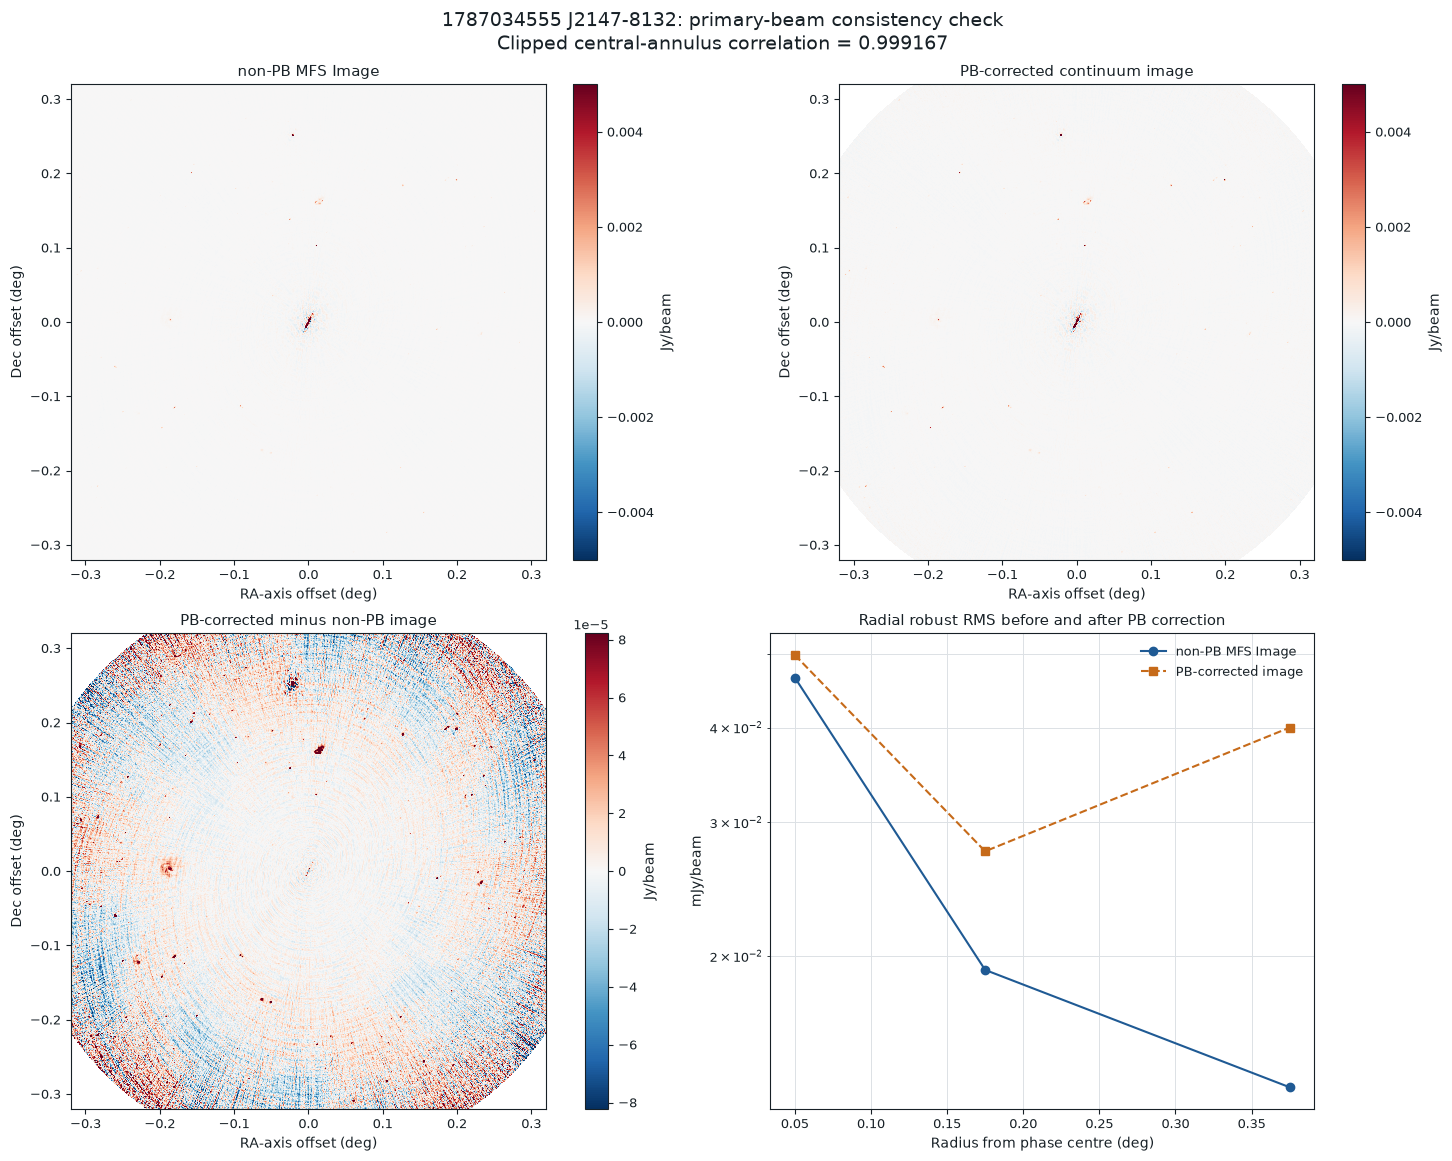

,central_pattern_correlation,median_abs_central_difference_mjy_beam,max_abs_central_difference_mjy_beam
0,0.999167,0.00254658,0.0355014


Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_06_pb_consistency_check.png


In [18]:
## Live code
PB_FIGURE_PATH = output_path("06_pb_consistency_check.png")
central_pattern_correlation_pb = np.nan
pb_check_summary = None

if PB_AVAILABLE:
    with fits.open(PB_IMAGE_PATH, memmap=True, do_not_scale_image_data=True) as pb_hdul:
        pb_image = np.asarray(pb_hdul[0].data).squeeze()
        pb_header = pb_hdul[0].header.copy()
    if pb_image.shape != INTENSITY_PLANE.shape:
        raise ValueError(
            f"PB image shape {pb_image.shape} does not match "
            f"non-PB intensity shape {INTENSITY_PLANE.shape}"
        )
    pb_sample = np.asarray(pb_image[::DISPLAY_STRIDE, ::DISPLAY_STRIDE])

    pb_central_vector = np.clip(
        pb_sample[central_annulus_mask],
        -PATTERN_CLIP_JY,
        PATTERN_CLIP_JY,
    )
    nonpb_central_vector = np.clip(
        intensity_sample[central_annulus_mask],
        -PATTERN_CLIP_JY,
        PATTERN_CLIP_JY
    )
    central_pattern_correlation_pb = float(np.corrcoef(
        nonpb_central_vector,
        pb_central_vector,
    )[0, 1])

    pb_crop = np.asarray(pb_image[
        crop_y0:crop_y1:CENTRAL_CROP_STRIDE,
        crop_x0:crop_x1:CENTRAL_CROP_STRIDE,
    ])
    nonpb_crop = np.asarray(INTENSITY_PLANE[
        crop_y0:crop_y1:CENTRAL_CROP_STRIDE,
        crop_x0:crop_x1:CENTRAL_CROP_STRIDE,
    ])
    difference_crop = pb_crop - nonpb_crop

    pb_radial_rows = []
    for lower_radius, upper_radius in zip(annulus_edges[:-1], annulus_edges[1:]):
        mask = (
            (sample_radius_deg >= lower_radius)
            & (sample_radius_deg < upper_radius)
            & np.isfinite(intensity_sample)
            & np.isfinite(pb_sample)
        )
        _, nonpb_rms, _ = robust_location_scale(intensity_sample[mask])
        _, pb_rms, _ = robust_location_scale(pb_sample[mask])
        pb_radial_rows.append({
            "radius_mid_deg": 0.5 * (lower_radius + upper_radius),
            "nonpb_rms_mjy_beam": 1e3 * nonpb_rms,
            "pb_rms_mjy_beam": 1e3 * pb_rms,
        })
    pb_radial_profile = pd.DataFrame(pb_radial_rows)

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 11.5), constrained_layout=True)
    for axis, image_data, title in (
        (axes[0, 0], nonpb_crop, "non-PB MFS Image"),
        (axes[0, 1], pb_crop, "PB-corrected continuum image"),
    ):
        displayed = axis.imshow(
            image_data,
            origin="lower",
            extent=central_extent_deg,
            cmap="RdBu_r",
            vmin=-COMMON_DISPLAY_LIMIT_MJY / 1e3,
            vmax=COMMON_DISPLAY_LIMIT_MJY / 1e3,
            interpolation="nearest",
        )
        axis.set_title(title)
        axis.set_xlabel("RA-axis offset (deg)")
        axis.set_ylabel("Dec offset (deg)")
        fig.colorbar(displayed, ax=axis, label="Jy/beam")

    difference_limit = np.nanpercentile(np.abs(difference_crop), 99.5)
    difference_display = axes[1, 0].imshow(
        difference_crop,
        origin="lower",
        extent=central_extent_deg,
        cmap="RdBu_r",
        vmin=-difference_limit,
        vmax=difference_limit,
        interpolation="nearest",
    )
    axes[1, 0].set_title("PB-corrected minus non-PB image")
    axes[1, 0].set_xlabel("RA-axis offset (deg)")
    axes[1, 0].set_ylabel("Dec offset (deg)")
    fig.colorbar(difference_display, ax=axes[1, 0], label="Jy/beam")

    axes[1, 1].plot(
        pb_radial_profile["radius_mid_deg"],
        pb_radial_profile["nonpb_rms_mjy_beam"],
        "o-", color=BLUE, label="non-PB MFS Image",
    )
    axes[1, 1].plot(
        pb_radial_profile["radius_mid_deg"],
        pb_radial_profile["pb_rms_mjy_beam"],
        "s--", color=ORANGE, label="PB-corrected image",
    )
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Radial robust RMS before and after PB correction")
    axes[1, 1].set_xlabel("Radius from phase centre (deg)")
    axes[1, 1].set_ylabel("mJy/beam")
    axes[1, 1].grid(True, which="both", color=GRID, linewidth=0.7)
    axes[1, 1].legend()

    fig.suptitle(
        f"{CBID} {TARGET_NAME}: primary-beam consistency check\n"
        f"Clipped central-annulus correlation = "
        f"{central_pattern_correlation_pb:.6f}",
        fontsize=1.4 * FIGURE_FONT_SIZE,
    )
    fig.savefig(PB_FIGURE_PATH, dpi=FIGURE_DPI)
    plt.show()

    pb_check_summary = pd.DataFrame([{
        "central_pattern_correlation": central_pattern_correlation_pb,
        "median_abs_central_difference_mjy_beam": 1e3 * np.nanmedian(
            np.abs(
                pb_sample[central_annulus_mask]
                - intensity_sample[central_annulus_mask]
            )
        ),
        "max_abs_central_difference_mjy_beam": 1e3 * np.nanmax(
            np.abs(
                pb_sample[central_annulus_mask]
                - intensity_sample[central_annulus_mask]
            )
        ),
    }])
    display(pb_check_summary.style.format("{:.6g}"))
    print(f"Saved: {PB_FIGURE_PATH}")
else:
    display(Markdown(
        f"> PB consistency check skipped: no companion file named "
        f"`{PB_IMAGE_PATH.name}` was found."
    ))

### 12. PB-corrected RMS and normalized-residual assessment

The RMS map supplies the expected spatial noise after primary-beam correction.
The diagnostic compares that prediction with the empirical image scatter and
displays `(PB image - background) / RMS`.

- A supplied RMS FITS is preferred and must match the PB image shape and WCS.
- Conventional `_PB_aegean_rms.fits`, `_PB_rms.fits` and `_PB-rms.fits` names are
  detected automatically.
- If no RMS FITS exists and `ESTIMATE_PB_RMS_IF_MISSING=True`, the notebook creates
  a robust, tile-based local estimate. This fallback is explicitly labelled and
  should not be treated as an independent pipeline noise product.
- This full-band check measures spatial significance, not subband health.

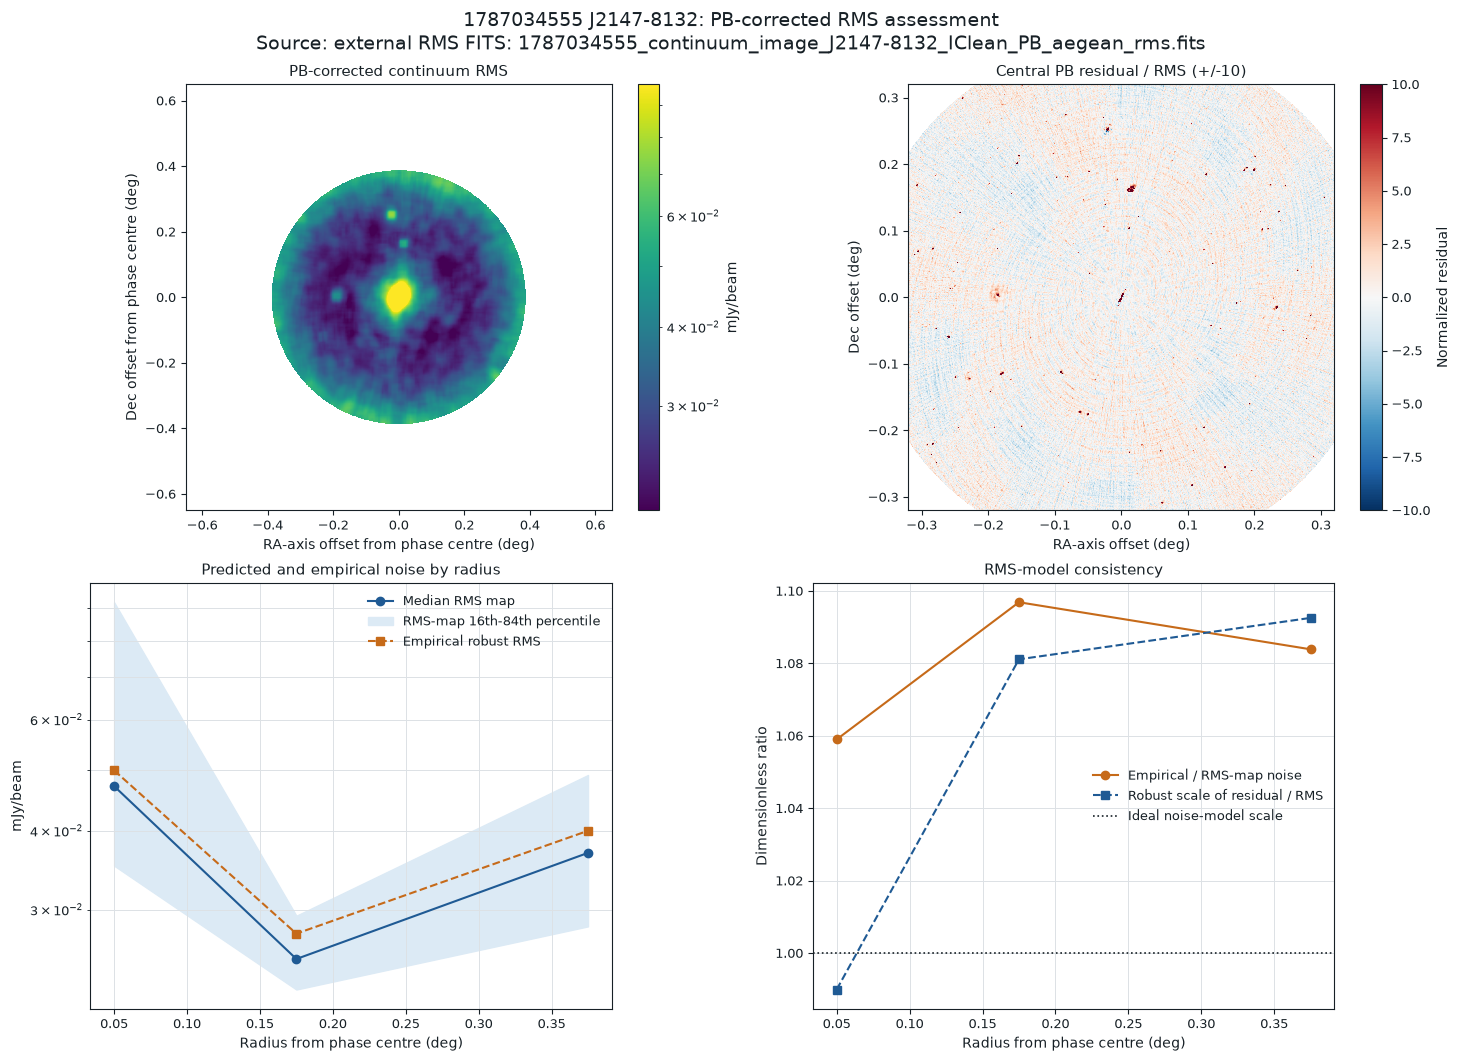

,rms_source,central_median_rms_mjy_beam,outer_median_rms_mjy_beam,outer_to_central_rms,outer_normalized_residual_robust_scale,outer_normalized_samples_kept,background_subtracted
0,external RMS FITS: 1787034555_continuum_image_J2147-8132_IClean_PB_aegean_rms.fits,0.04654,0.0369,0.793,1.093,608506,False


Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_07_pb_rms_assessment.png
Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_pb_rms_radial_metrics.csv


**Interpretation:** The external RMS FITS: 1787034555_continuum_image_J2147-8132_IClean_PB_aegean_rms.fits has median RMS 0.0465 mJy/beam in the central annulus and 0.0369 mJy/beam in the outer annulus. The outer-field normalized residual scale is close to unity, so the external RMS model is broadly consistent with the pixel scatter.

In [19]:
## Live code 
PB_RMS_FIGURE_PATH = output_path("07_pb_rms_assessment.png")
PB_RMS_METRICS_PATH = output_path("pb_rms_radial_metrics.csv")
PB_RMS_ANALYSIS_AVAILABLE = False
PB_RMS_SOURCE = None
pb_rms_summary = None
pb_rms_radial_profile = None
pb_rms_assessment = (
    "No PB-corrected image is available, so an RMS-normalized PB assessment "
    "cannot be performed."
)

def validate_companion_wcs(companion_header, companion_shape, label):
    if companion_shape != INTENSITY_PLANE.shape:
        raise ValueError(
            f"{label} shape {companion_shape} does not match "
            f"image shape {INTENSITY_PLANE.shape}"
        )
    for key in ("CRPIX1", "CRPIX2", "CRVAL1", "CRVAL2", "CDELT1", "CDELT2"):
        if key in companion_header and key in pb_header:
            if not np.isclose(
                float(companion_header[key]),
                float(pb_header[key]),
                rtol=0.0,
                atol=1e-10,
            ):
                raise ValueError(
                    f"{label} WCS mismatch in {key}: "
                    f"{companion_header[key]} versus {pb_header[key]}"
                )

def image_to_jy_per_beam(image, header, label):
    unit = str(header.get("BUNIT", "Jy/beam")).strip().lower()
    image = np.asarray(image, dtype=np.float64)
    if "mjy" in unit:
        return image / 1e3
    if "jy" in unit or not unit:
        return image
    warnings.warn(
        f"{label} has unrecognized BUNIT={header.get('BUNIT')!r}; "
        "assuming Jy/beam."
    )
    return image

def interpolate_tile_grid(tile_grid, tile_y, tile_x, output_shape):
    output_y = np.arange(output_shape[0], dtype=float)
    output_x = np.arange(output_shape[1], dtype=float)
    interpolated_x = np.vstack([
        np.interp(output_x, tile_x, row)
        for row in tile_grid
    ])
    return np.vstack([
        np.interp(output_y, tile_y, interpolated_x[:, column])
        for column in range(output_shape[1])
    ]).T

if PB_AVAILABLE:
    if PB_BACKGROUND_AVAILABLE:
        with fits.open(
            PB_BACKGROUND_IMAGE_PATH,
            memmap=True,
            do_not_scale_image_data=True,
        ) as background_hdul:
            pb_background = np.asarray(background_hdul[0].data).squeeze()
            pb_background_header = background_hdul[0].header.copy()
        validate_companion_wcs(
            pb_background_header,
            pb_background.shape,
            "PB background image",
        )
        pb_background = image_to_jy_per_beam(
            pb_background,
            pb_background_header,
            "PB background image",
        )
        pb_background_sample = pb_background[::DISPLAY_STRIDE, ::DISPLAY_STRIDE]
    else:
        pb_background_sample = np.zeros_like(pb_sample, dtype=np.float64)

    pb_residual_sample = (
        np.asarray(pb_sample, dtype=np.float64) - pb_background_sample
    )

    if PB_RMS_EXTERNAL_AVAILABLE:
        with fits.open(
            PB_RMS_IMAGE_PATH,
            memmap=True,
            do_not_scale_image_data=True,
        ) as rms_hdul:
            pb_rms_image = np.asarray(rms_hdul[0].data).squeeze()
            pb_rms_header = rms_hdul[0].header.copy()
        validate_companion_wcs(
            pb_rms_header,
            pb_rms_image.shape,
            "PB RMS image",
        )
        pb_rms_image = image_to_jy_per_beam(
            pb_rms_image,
            pb_rms_header,
            "PB RMS image",
        )
        pb_rms_sample = pb_rms_image[::DISPLAY_STRIDE, ::DISPLAY_STRIDE]
        PB_RMS_SOURCE = f"external RMS FITS: {PB_RMS_IMAGE_PATH.name}"
    elif ESTIMATE_PB_RMS_IF_MISSING:
        sample_tile_size = max(
            8,
            int(round(RMS_ESTIMATION_TILE_PIXELS / DISPLAY_STRIDE)),
        )
        sample_height, sample_width = pb_residual_sample.shape
        y_starts = np.arange(0, sample_height, sample_tile_size)
        x_starts = np.arange(0, sample_width, sample_tile_size)
        tile_rms = np.full((len(y_starts), len(x_starts)), np.nan)

        for tile_y_index, y_start in enumerate(y_starts):
            y_stop = min(sample_height, y_start + sample_tile_size)
            for tile_x_index, x_start in enumerate(x_starts):
                x_stop = min(sample_width, x_start + sample_tile_size)
                _, local_rms, kept = robust_location_scale(
                    pb_residual_sample[y_start:y_stop, x_start:x_stop]
                )
                if kept >= max(20, sample_tile_size):
                    tile_rms[tile_y_index, tile_x_index] = local_rms

        _, fallback_rms, _ = robust_location_scale(
            pb_residual_sample[background_annulus_mask]
        )
        if not np.isfinite(fallback_rms) or fallback_rms <= 0:
            _, fallback_rms, _ = robust_location_scale(pb_residual_sample)
        tile_rms = np.where(
            np.isfinite(tile_rms) & (tile_rms > 0),
            tile_rms,
            fallback_rms,
        )
        tile_y_centres = np.minimum(
            y_starts + 0.5 * sample_tile_size,
            sample_height - 1,
        )
        tile_x_centres = np.minimum(
            x_starts + 0.5 * sample_tile_size,
            sample_width - 1,
        )
        pb_rms_sample = interpolate_tile_grid(
            tile_rms,
            tile_y_centres,
            tile_x_centres,
            pb_residual_sample.shape,
        )
        PB_RMS_SOURCE = (
            f"robust local estimate from PB image "
            f"({RMS_ESTIMATION_TILE_PIXELS}-pixel tiles)"
        )
    else:
        pb_rms_sample = None

    if pb_rms_sample is not None:
        valid_rms = np.isfinite(pb_rms_sample) & (pb_rms_sample > 0)
        valid_residual = np.isfinite(pb_residual_sample)
        normalized_residual = np.full_like(pb_residual_sample, np.nan)
        normalized_residual[valid_rms & valid_residual] = (
            pb_residual_sample[valid_rms & valid_residual]
            / pb_rms_sample[valid_rms & valid_residual]
        )

        rms_radial_rows = []
        for lower_radius, upper_radius in zip(
            annulus_edges[:-1],
            annulus_edges[1:],
        ):
            mask = (
                (sample_radius_deg >= lower_radius)
                & (sample_radius_deg < upper_radius)
                & valid_rms
                & valid_residual
            )
            _, empirical_rms, empirical_kept = robust_location_scale(
                pb_residual_sample[mask]
            )
            _, normalized_scale, normalized_kept = robust_location_scale(
                normalized_residual[mask]
            )
            rms_values = pb_rms_sample[mask]
            rms_radial_rows.append({
                "radius_mid_deg": 0.5 * (lower_radius + upper_radius),
                "radius_min_deg": lower_radius,
                "radius_max_deg": upper_radius,
                "median_rms_mjy_beam": 1e3 * np.nanmedian(rms_values),
                "rms_p16_mjy_beam": 1e3 * np.nanpercentile(rms_values, 16),
                "rms_p84_mjy_beam": 1e3 * np.nanpercentile(rms_values, 84),
                "empirical_rms_mjy_beam": 1e3 * empirical_rms,
                "empirical_to_map_rms": (
                    empirical_rms / np.nanmedian(rms_values)
                ),
                "normalized_residual_robust_scale": normalized_scale,
                "empirical_samples_kept": empirical_kept,
                "normalized_samples_kept": normalized_kept,
            })
        pb_rms_radial_profile = pd.DataFrame(rms_radial_rows)
        pb_rms_radial_profile.to_csv(PB_RMS_METRICS_PATH, index=False)

        central_rms_values = pb_rms_sample[central_annulus_mask & valid_rms]
        outer_rms_values = pb_rms_sample[background_annulus_mask & valid_rms]
        _, outer_normalized_scale, outer_normalized_kept = robust_location_scale(
            normalized_residual[
                background_annulus_mask
                & np.isfinite(normalized_residual)
            ]
        )

        sample_crop_y0 = max(0, int(np.floor(crop_y0 / DISPLAY_STRIDE)))
        sample_crop_y1 = min(
            pb_rms_sample.shape[0],
            int(np.ceil(crop_y1 / DISPLAY_STRIDE)),
        )
        sample_crop_x0 = max(0, int(np.floor(crop_x0 / DISPLAY_STRIDE)))
        sample_crop_x1 = min(
            pb_rms_sample.shape[1],
            int(np.ceil(crop_x1 / DISPLAY_STRIDE)),
        )
        normalized_crop = normalized_residual[
            sample_crop_y0:sample_crop_y1,
            sample_crop_x0:sample_crop_x1,
        ]

        positive_rms_values = pb_rms_sample[valid_rms]
        rms_display_min, rms_display_max = np.nanpercentile(
            positive_rms_values,
            [1, 99],
        )
        if rms_display_max <= rms_display_min:
            rms_display_max = rms_display_min * 1.01

        fig, axes = plt.subplots(
            2, 2,
            figsize=(14.5, 10.5),
            constrained_layout=True,
        )
        rms_display = axes[0, 0].imshow(
            1e3 * pb_rms_sample,
            origin="lower",
            extent=full_extent_deg,
            cmap="viridis",
            norm=LogNorm(
                vmin=1e3 * rms_display_min,
                vmax=1e3 * rms_display_max,
            ),
            interpolation="nearest",
        )
        axes[0, 0].set_title("PB-corrected continuum RMS")
        axes[0, 0].set_xlabel("RA-axis offset from phase centre (deg)")
        axes[0, 0].set_ylabel("Dec offset from phase centre (deg)")
        fig.colorbar(rms_display, ax=axes[0, 0], label="mJy/beam")

        normalized_display = axes[0, 1].imshow(
            normalized_crop,
            origin="lower",
            extent=central_extent_deg,
            cmap="RdBu_r",
            vmin=-NORMALIZED_RESIDUAL_LIMIT,
            vmax=NORMALIZED_RESIDUAL_LIMIT,
            interpolation="nearest",
        )
        axes[0, 1].set_title(
            f"Central PB residual / RMS "
            f"(+/-{NORMALIZED_RESIDUAL_LIMIT:g})"
        )
        axes[0, 1].set_xlabel("RA-axis offset (deg)")
        axes[0, 1].set_ylabel("Dec offset (deg)")
        fig.colorbar(
            normalized_display,
            ax=axes[0, 1],
            label="Normalized residual",
        )

        axes[1, 0].plot(
            pb_rms_radial_profile["radius_mid_deg"],
            pb_rms_radial_profile["median_rms_mjy_beam"],
            "o-", color=BLUE, label="Median RMS map",
        )
        axes[1, 0].fill_between(
            pb_rms_radial_profile["radius_mid_deg"],
            pb_rms_radial_profile["rms_p16_mjy_beam"],
            pb_rms_radial_profile["rms_p84_mjy_beam"],
            color=PALE_BLUE,
            label="RMS-map 16th-84th percentile",
        )
        axes[1, 0].plot(
            pb_rms_radial_profile["radius_mid_deg"],
            pb_rms_radial_profile["empirical_rms_mjy_beam"],
            "s--", color=ORANGE, label="Empirical robust RMS",
        )
        axes[1, 0].set_yscale("log")
        axes[1, 0].set_title("Predicted and empirical noise by radius")
        axes[1, 0].set_xlabel("Radius from phase centre (deg)")
        axes[1, 0].set_ylabel("mJy/beam")
        axes[1, 0].grid(True, which="both", color=GRID, linewidth=0.7)
        axes[1, 0].legend()

        axes[1, 1].plot(
            pb_rms_radial_profile["radius_mid_deg"],
            pb_rms_radial_profile["empirical_to_map_rms"],
            "o-", color=ORANGE, label="Empirical / RMS-map noise",
        )
        axes[1, 1].plot(
            pb_rms_radial_profile["radius_mid_deg"],
            pb_rms_radial_profile["normalized_residual_robust_scale"],
            "s--", color=BLUE, label="Robust scale of residual / RMS",
        )
        axes[1, 1].axhline(
            1.0,
            color=INK,
            linestyle=":",
            linewidth=1.2,
            label="Ideal noise-model scale",
        )
        axes[1, 1].set_title("RMS-model consistency")
        axes[1, 1].set_xlabel("Radius from phase centre (deg)")
        axes[1, 1].set_ylabel("Dimensionless ratio")
        axes[1, 1].grid(True, color=GRID, linewidth=0.7)
        axes[1, 1].legend()

        fig.suptitle(
            f"{CBID} {TARGET_NAME}: PB-corrected RMS assessment\n"
            f"Source: {PB_RMS_SOURCE}",
            fontsize=1.4 * FIGURE_FONT_SIZE,
        )
        fig.savefig(PB_RMS_FIGURE_PATH, dpi=FIGURE_DPI)
        plt.show()

        central_rms_median_mjy = 1e3 * np.nanmedian(central_rms_values)
        outer_rms_median_mjy = 1e3 * np.nanmedian(outer_rms_values)
        pb_rms_summary = pd.DataFrame([{
            "rms_source": PB_RMS_SOURCE,
            "central_median_rms_mjy_beam": central_rms_median_mjy,
            "outer_median_rms_mjy_beam": outer_rms_median_mjy,
            "outer_to_central_rms": (
                outer_rms_median_mjy / central_rms_median_mjy
            ),
            "outer_normalized_residual_robust_scale": outer_normalized_scale,
            "outer_normalized_samples_kept": outer_normalized_kept,
            "background_subtracted": PB_BACKGROUND_AVAILABLE,
        }])
        display(pb_rms_summary.style.format({
            "central_median_rms_mjy_beam": "{:.4g}",
            "outer_median_rms_mjy_beam": "{:.4g}",
            "outer_to_central_rms": "{:.3f}",
            "outer_normalized_residual_robust_scale": "{:.3f}",
        }))

        if not PB_RMS_EXTERNAL_AVAILABLE:
            consistency_text = (
                "The normalized residual scale is expected to be near unity "
                "because this fallback RMS was estimated from the same PB image; "
                "it is not an independent validation of the pipeline noise model."
            )
        elif 0.8 <= outer_normalized_scale <= 1.2:
            consistency_text = (
                "The outer-field normalized residual scale is close to unity, "
                "so the external RMS model is broadly consistent with the pixel scatter."
            )
        elif outer_normalized_scale > 1.2:
            consistency_text = (
                "The outer-field normalized residual scale exceeds unity, "
                "indicating underestimated noise or additional structured residuals."
            )
        else:
            consistency_text = (
                "The outer-field normalized residual scale is below unity, "
                "indicating a conservative or overestimated external RMS model."
            )
        pb_rms_assessment = (
            f"The {PB_RMS_SOURCE} has median RMS "
            f"{central_rms_median_mjy:.3g} mJy/beam in the central annulus and "
            f"{outer_rms_median_mjy:.3g} mJy/beam in the outer annulus. "
            f"{consistency_text}"
        )
        PB_RMS_ANALYSIS_AVAILABLE = True
        print(f"Saved: {PB_RMS_FIGURE_PATH}")
        print(f"Saved: {PB_RMS_METRICS_PATH}")
    else:
        pb_rms_assessment = (
            "No external PB RMS image was found and local estimation is disabled."
        )
else:
    display(Markdown(f"> {pb_rms_assessment}"))

if PB_RMS_ANALYSIS_AVAILABLE:
    display(Markdown(f"**Interpretation:** {pb_rms_assessment}"))

## Takeaways

The following interpretation is generated from the measured subband statistics.
It distinguishes image-domain evidence from possible upstream causes; it does not
attribute a failure to the correlator without visibility-, polarization- or
calibration-domain confirmation.

In [20]:
## Assessment summary code
if severe_count:
    frequency_assessment = (
        f"{severe_count} of {NSPEC} subbands exceed the configured outer-field "
        f"RMS threshold. Because the failures occur at {severe_frequency_text} MHz, "
        "inspect the image matrices for separated, coherent structures before "
        "treating the non-PB MFS Image as representative of the full band."
    )
    fitness_assessment = (
        "The observation should not pass in-band spectral/frequency-response QA "
        "without qualification. Bright-source full-band measurements may remain "
        "usable, but faint-source and spectral products require caveats."
    )
else:
    frequency_assessment = (
        f"No subband exceeds the configured {SEVERE_RMS_THRESHOLD_MJY:g} mJy/beam "
        "outer-field threshold. This is not by itself a correlator pass; inspect "
        "the source spectrum, morphology and central-to-outer RMS ratios."
    )
    fitness_assessment = (
        "No severe frequency-localized image-noise failure is detected by this "
        "threshold. Remaining morphology and reference-image checks still apply."
    )

if PB_AVAILABLE and np.isfinite(central_pattern_correlation_pb):
    pb_assessment = (
        f"The central non-PB/PB pattern correlation is "
        f"{central_pattern_correlation_pb:.6f}. "
        + (
            "Near-unity agreement makes PB correction an unlikely origin of the "
            "central artifact morphology."
            if central_pattern_correlation_pb >= 0.99
            else "The PB and non-PB central patterns differ materially; inspect "
                 "registration, plane selection and PB handling before drawing "
                 "a causal conclusion."
        )
    )
else:
    pb_assessment = (
        "No PB-corrected companion was available, so the PB consistency check "
        "is not part of this observation's assessment."
    )

observation_assessment_markdown = f"""### Observation assessment — CBID `{CBID}`

{frequency_assessment}

{pb_assessment}

{pb_rms_assessment}

**Fitness for use:** {fitness_assessment}
"""

takeaways_markdown = f"""{observation_assessment_markdown}

### Candidate causes to test without recalibration

1. Re-image the existing corrected visibilities separately by receptor/polarization.
2. Produce dirty/PSF-only images for the affected subbands using the existing flags.
3. Compare per-scan subband images to isolate time-localized failures.
4. Compare flag fraction, bandpass/delay residuals and source spectra at the same
   subband boundaries.
5. Recalibrate only if these tests cannot isolate the failure.

### Reproducibility

- Analysis timestamp: `{ANALYSIS_TIMESTAMP_ISO}`
- Observation date: `{OBSERVATION_DATE}`
- Instrument / correlator mode: `{INSTRUMENT_MODE}`
- Band code: `{BAND_CODE}`
- Frequency range: `{FREQUENCY_RANGE_TEXT}`
- Clean beam: `{CLEAN_BEAM_TEXT}`
- Input: `{CUBOID_PATH}`
- CBID: `{CBID}`
- Output directory: `{OUTPUT_DIR}`
- Display/statistics stride: `{DISPLAY_STRIDE}`
- Severe RMS threshold: `{SEVERE_RMS_THRESHOLD_MJY:g} mJy/beam`
- The FITS files are opened read-only and are never modified.
"""
display(Markdown(takeaways_markdown))

### Observation assessment — CBID `1787034555`

No subband exceeds the configured 10 mJy/beam outer-field threshold. This is not by itself a correlator pass; inspect the source spectrum, morphology and central-to-outer RMS ratios.

The central non-PB/PB pattern correlation is 0.999167. Near-unity agreement makes PB correction an unlikely origin of the central artifact morphology.

The external RMS FITS: 1787034555_continuum_image_J2147-8132_IClean_PB_aegean_rms.fits has median RMS 0.0465 mJy/beam in the central annulus and 0.0369 mJy/beam in the outer annulus. The outer-field normalized residual scale is close to unity, so the external RMS model is broadly consistent with the pixel scatter.

**Fitness for use:** No severe frequency-localized image-noise failure is detected by this threshold. Remaining morphology and reference-image checks still apply.


### Candidate causes to test without recalibration

1. Re-image the existing corrected visibilities separately by receptor/polarization.
2. Produce dirty/PSF-only images for the affected subbands using the existing flags.
3. Compare per-scan subband images to isolate time-localized failures.
4. Compare flag fraction, bandpass/delay residuals and source spectra at the same
   subband boundaries.
5. Recalibrate only if these tests cannot isolate the failure.

### Reproducibility

- Analysis timestamp: `2026-08-19T10:03:13+02:00`
- Observation date: `2026-08-18`
- Instrument / correlator mode: `c875M1k`
- Band code: `S`
- Frequency range: `2625.000-3499.146 MHz (2.625000-3.499146 GHz)`
- Clean beam: `5.145 x 3.826 arcsec, PA -50.041310 deg`
- Input: `/Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/images/1787034555_continuum_image_J2147-8132_IClean.fits`
- CBID: `1787034555`
- Output directory: `/Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment`
- Display/statistics stride: `4`
- Severe RMS threshold: `10 mJy/beam`
- The FITS files are opened read-only and are never modified.


In [21]:
# PDF Builder: code-free, observation-specific PDF report.
REPORT_PDF_PATH = output_path("mfimage_frequency_assessment.pdf")
SUMMARY_JSON_PATH = output_path("mfimage_frequency_assessment_summary.json")

summary_payload = {
    "analysis_timestamp": ANALYSIS_TIMESTAMP_ISO,
    "analysis_date": ANALYSIS_DATE,
    "analysis_timezone": ANALYSIS_TIMEZONE,
    "cbid": CBID,
    "target": TARGET_NAME,
    "input_fits": str(CUBOID_PATH),
    "observation_metadata_csv": str(OBSERVATION_METADATA_PATH),
    "object": OBSERVATION_OBJECT,
    "telescope": TELESCOPE,
    "instrument_correlator_mode": INSTRUMENT_MODE,
    "band_code": BAND_CODE,
    "observation_date": OBSERVATION_DATE,
    "map_date": MAP_DATE,
    "observer_project": OBSERVER_PROJECT,
    "frequency_min_mhz": FREQUENCY_MIN_MHZ,
    "frequency_max_mhz": FREQUENCY_MAX_MHZ,
    "frequency_range_source": FREQUENCY_RANGE_SOURCE,
    "clean_beam_major_arcsec": CLEAN_BEAM_MAJOR_ARCSEC,
    "clean_beam_minor_arcsec": CLEAN_BEAM_MINOR_ARCSEC,
    "clean_beam_pa_deg": CLEAN_BEAM_PA_DEG,
    "clean_beam_source_keys": {
        "major": CLEAN_BEAM_MAJOR_SOURCE_KEY,
        "minor": CLEAN_BEAM_MINOR_SOURCE_KEY,
        "position_angle": CLEAN_BEAM_PA_SOURCE_KEY,
    },
    "pb_companion": str(PB_IMAGE_PATH) if PB_AVAILABLE else None,
    "reference_frequency_mhz": REFERENCE_FREQUENCY_HZ / 1e6,
    "nterm": NTERM,
    "nspec": NSPEC,
    "display_stride": DISPLAY_STRIDE,
    "severe_rms_threshold_mjy_beam": SEVERE_RMS_THRESHOLD_MJY,
    "central_annulus_deg": [
        CENTRAL_ANNULUS_INNER_DEG,
        CENTRAL_ANNULUS_OUTER_DEG,
    ],
    "background_annulus_deg": [
        BACKGROUND_ANNULUS_INNER_DEG,
        BACKGROUND_ANNULUS_OUTER_DEG,
    ],
    "robust_clip_sigma": ROBUST_CLIP_SIGMA,
    "robust_clip_iterations": ROBUST_CLIP_ITERATIONS,
    "severe_subband_count": severe_count,
    "severe_subband_frequencies_mhz": severe_rows["frequency_mhz"].tolist(),
    "lower_noise_spectral_index": (
        lower_noise_alpha if np.isfinite(lower_noise_alpha) else None
    ),
    "mfimage_alpha_at_peak": alpha_at_intensity_peak,
    "pb_central_pattern_correlation": (
        central_pattern_correlation_pb
        if np.isfinite(central_pattern_correlation_pb)
        else None
    ),
    "pb_rms_source": PB_RMS_SOURCE,
    "pb_rms_analysis_available": PB_RMS_ANALYSIS_AVAILABLE,
    "pb_rms_central_median_mjy_beam": (
        float(pb_rms_summary.iloc[0]["central_median_rms_mjy_beam"])
        if PB_RMS_ANALYSIS_AVAILABLE else None
    ),
    "pb_rms_outer_median_mjy_beam": (
        float(pb_rms_summary.iloc[0]["outer_median_rms_mjy_beam"])
        if PB_RMS_ANALYSIS_AVAILABLE else None
    ),
    "pb_rms_outer_normalized_residual_scale": (
        float(pb_rms_summary.iloc[0]["outer_normalized_residual_robust_scale"])
        if PB_RMS_ANALYSIS_AVAILABLE else None
    ),
}
SUMMARY_JSON_PATH.write_text(json.dumps(summary_payload, indent=2) + "\n")

report_figures = [
    (
        output_path("01_combined_plane_diagnostic.png"),
        "non-PB MFS Image diagnostic",
        "The symmetric-log and common-scale views expose low-level residual "
        "structure; the radial panel compares central and outer-field behavior.",
    ),
    (
        output_path("02_subband_common_scale.png"),
        "Independent subbands on a common physical scale",
        "All subbands use the same Jy/beam limits. Saturation identifies planes "
        "that are not directly comparable with the lower-noise images.",
    ),
    (
        output_path("03_subband_sigma_scale.png"),
        "Independent subbands in local-noise units",
        "Each image is normalized by its own outer-field robust RMS. This view "
        "emphasizes morphology and must be read with the common-scale matrix.",
    ),
    (
        output_path("04_frequency_metrics.png"),
        "Frequency-dependent metrics",
        "RMS, source-spectrum consistency, signed tails and morphology correlation "
        "provide complementary evidence for frequency-localized degradation.",
    ),
    (
        output_path("05_spectral_index_quality.png"),
        "Spectral-index reliability",
        "Default-valued pixels are not flat-spectrum measurements. The displayed "
        "map is restricted to bright, non-default pixels.",
    ),
]
if PB_AVAILABLE:
    report_figures.append((
        PB_FIGURE_PATH,
        "Primary-beam consistency check",
        "The matched central images and radial profiles test whether PB correction "
        "created or merely rescaled the observed artifact structure.",
    ))
if PB_RMS_ANALYSIS_AVAILABLE:
    report_figures.append((
        PB_RMS_FIGURE_PATH,
        "PB-corrected RMS and normalized residuals",
        "The spatial noise model is compared with empirical pixel scatter; "
        "the normalized-residual map highlights structure that exceeds the "
        "local continuum noise expectation.",
    ))

def add_footer(figure, page_number):
    figure.text(
        0.04, 0.025,
        f"CBID {CBID} | Analysis {ANALYSIS_DATE} | MFImage frequency assessment",
        ha="left", va="bottom", fontsize=8, color=MUTED,
    )
    figure.text(
        0.96, 0.025, str(page_number),
        ha="right", va="bottom", fontsize=8, color=MUTED,
    )

def add_text_page(pdf, title, sections, page_number):
    page = plt.figure(figsize=(8.27, 11.69))
    axis = page.add_axes([0.08, 0.07, 0.84, 0.86])
    axis.axis("off")
    axis.text(
        0, 1.0, title, ha="left", va="top",
        fontsize=20, fontweight="bold", color=INK,
    )
    y = 0.92
    for heading, body in sections:
        axis.text(
            0, y, heading, ha="left", va="top",
            fontsize=13, fontweight="bold", color=BLUE,
        )
        y -= 0.045
        wrapped = "\n".join(textwrap.wrap(body, width=92))
        axis.text(
            0, y, wrapped, ha="left", va="top",
            fontsize=10.2, color=INK, linespacing=1.35,
        )
        y -= 0.033 * (wrapped.count("\n") + 1) + 0.045
    add_footer(page, page_number)
    pdf.savefig(page, bbox_inches="tight")
    plt.close(page)

def add_subband_table_page(pdf, table_frame, page_number, row_offset=0):
    page = plt.figure(figsize=(11.69, 8.27))
    axis = page.add_axes([0.035, 0.13, 0.93, 0.74])
    axis.axis("off")

    column_labels = [
        "Subband", "Frequency\n(MHz)", "Outer RMS\n(mJy/beam)",
        "Central RMS\n(mJy/beam)", "RMS /\nbest", "Peak\n(Jy/beam)",
        "Peak residual\n(%)", "Peak shift\n(arcsec)", "Assessment",
    ]
    cell_text = []
    for _, row in table_frame.iterrows():
        cell_text.append([
            f"{int(row['subband'])}",
            f"{row['frequency_mhz']:.1f}",
            f"{row['outer_rms_mjy_beam']:.3f}",
            f"{row['central_rms_mjy_beam']:.3f}",
            f"{row['rms_vs_best']:.1f}x",
            f"{row['peak_jy_beam']:.3f}",
            f"{row['peak_residual_percent']:+.1f}%",
            f"{row['peak_shift_arcsec']:.2f}",
            str(row['assessment']),
        ])

    table = axis.table(
        cellText=cell_text,
        colLabels=column_labels,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=[0.06, 0.09, 0.105, 0.105, 0.075, 0.09, 0.10, 0.09, 0.17],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(max(6.5, 0.78 * FIGURE_FONT_SIZE))
    table.scale(1.0, 1.55)
    for (row_index, column_index), cell in table.get_celld().items():
        cell.set_edgecolor(GRID)
        cell.set_linewidth(0.7)
        if row_index == 0:
            cell.set_facecolor(BLUE)
            cell.set_text_props(color="white", fontweight="bold")
        elif table_frame.iloc[row_index - 1]['assessment'] == "severe corruption":
            cell.set_facecolor("#FCE8E6")
        elif row_index % 2 == 0:
            cell.set_facecolor("#F4F7F9")

    final_row = row_offset + len(table_frame)
    page.suptitle(
        "Independent subband measurements",
        y=0.965,
        fontsize=1.6 * FIGURE_FONT_SIZE,
        fontweight="bold",
        color=INK,
    )
    page.text(
        0.05, 0.09,
        "The table reproduces Section 6 of the notebook. Red rows exceed the "
        f"{SEVERE_RMS_THRESHOLD_MJY:g} mJy/beam outer-field RMS threshold. "
        f"Rows {row_offset + 1}-{final_row} of {len(subband_metrics)} are shown.",
        ha="left", va="center", fontsize=0.95 * FIGURE_FONT_SIZE, color=INK,
    )
    add_footer(page, page_number)
    pdf.savefig(page)
    plt.close(page)

def add_image_page(pdf, image_path, title, caption, page_number):
    image_data = plt.imread(image_path)
    page = plt.figure(figsize=(11.69, 8.27))
    axis = page.add_axes([0.035, 0.11, 0.93, 0.79])
    axis.imshow(image_data)
    axis.axis("off")
    page.suptitle(title, y=0.965, fontsize=16, fontweight="bold", color=INK)
    page.text(
        0.05, 0.065,
        "\n".join(textwrap.wrap(caption, width=135)),
        ha="left", va="center", fontsize=9.5, color=INK,
    )
    add_footer(page, page_number)
    pdf.savefig(page)
    plt.close(page)

with PdfPages(REPORT_PDF_PATH) as pdf:
    metadata = pdf.infodict()
    metadata["Title"] = f"CBID {CBID} MFImage frequency QA {INSTRUMENT_MODE}"
    metadata["Subject"] = "Code-free summary of frequency-dependent image QA"
    metadata["Keywords"] = "MeerKAT, MFImage, continuum, subband, image QA"
    metadata["Author"] = str(OBSERVER_PROJECT)

    page_number = 1
    add_text_page(
        pdf,
        f"CBID {CBID}: MFImage frequency QA {INSTRUMENT_MODE}",
        [
            (
                "Analysis provenance",
                f"Analysis date {ANALYSIS_DATE}; run timestamp "
                f"{ANALYSIS_TIMESTAMP_ISO}. Input {CUBOID_PATH.name}.",
            ),
            (
                "Observation",
                f"Target {TARGET_NAME}; observation date {OBSERVATION_DATE}; "
                f"instrument/correlator mode {INSTRUMENT_MODE}; "
                f"band {BAND_CODE}; {NSPEC} subbands.",
            ),
            ("Subband result", frequency_assessment),
            (
                "Primary-beam and RMS checks",
                pb_assessment + " " + pb_rms_assessment,
            ),
            ("Fitness for use", fitness_assessment),
        ],
        page_number,
    )
    page_number += 1
    add_text_page(
        pdf,
        "Observation metadata and provenance",
        [
            (
                "Observation",
                f"CBID {CBID}; FITS object {OBSERVATION_OBJECT}; target "
                f"{TARGET_NAME}; observation date {OBSERVATION_DATE}; map date "
                f"{MAP_DATE}; observer/project {OBSERVER_PROJECT}.",
            ),
            (
                "Instrument",
                f"Telescope {TELESCOPE}; instrument/correlator mode "
                f"{INSTRUMENT_MODE} (INSTRUME); band code {BAND_CODE} "
                f"({BAND_SOURCE_KEY or 'not recorded'}).",
            ),
            (
                "Frequency coverage",
                f"{FREQUENCY_RANGE_TEXT}; derived from "
                f"{FREQUENCY_RANGE_SOURCE}. Reference frequency "
                f"{REFERENCE_FREQUENCY_HZ / 1e6:.3f} MHz (RFALPHA); "
                f"{NSPEC} independent subbands.",
            ),
            (
                "Clean beam",
                f"Major FWHM {CLEAN_BEAM_MAJOR_ARCSEC:.3f} arcsec; "
                f"minor FWHM {CLEAN_BEAM_MINOR_ARCSEC:.3f} arcsec; "
                f"position angle "
                f"{CLEAN_BEAM_PA_DEG:.6f} deg. Header sources: "
                f"{CLEAN_BEAM_MAJOR_SOURCE_KEY}, {CLEAN_BEAM_MINOR_SOURCE_KEY}, "
                f"{CLEAN_BEAM_PA_SOURCE_KEY}. Clean iterations: "
                f"{CLEAN_ITERATIONS}.",
            ),
            (
                "Method",
                f"Robust noise uses iterative {ROBUST_CLIP_SIGMA:g}-sigma "
                f"clipping on every {DISPLAY_STRIDE}th pixel. Severe "
                f"classification uses an outer-field RMS threshold of "
                f"{SEVERE_RMS_THRESHOLD_MJY:g} mJy/beam.",
            ),
            (
                "Analysis",
                f"Analysis date {ANALYSIS_DATE}; timestamp "
                f"{ANALYSIS_TIMESTAMP_ISO}; timezone {ANALYSIS_TIMEZONE}. "
                f"FITS writer {FITS_ORIGIN}.",
            ),
        ],
        page_number,
    )
    for row_offset in range(0, len(subband_metrics), 16):
        page_number += 1
        add_subband_table_page(
            pdf,
            subband_metrics.iloc[row_offset:row_offset + 16],
            page_number,
            row_offset,
        )
    for image_path, title, caption in report_figures:
        page_number += 1
        add_image_page(pdf, image_path, title, caption, page_number)
    page_number += 1
    add_text_page(
        pdf,
        "Interpretation and next checks",
        [
            (
                "Evidence boundary",
                "The notebook measures image-domain frequency dependence. "
                "Coherent structures confined to particular subbands support "
                "frequency-localized visibility, calibration, RFI or data-path "
                "corruption, but do not identify the correlator as the sole cause.",
            ),
            (
                "No-recalibration checks",
                "Re-image corrected data by receptor/polarization; make dirty and "
                "PSF-only subband images using the existing flags; compare per-scan "
                "subband images; and align flagging and calibration residuals with "
                "the affected frequency intervals.",
            ),
            (
                "PB RMS interpretation",
                pb_rms_assessment,
            ),
            (
                "Machine-readable outputs",
                f"Observation metadata: {OBSERVATION_METADATA_PATH.name}. "
                f"Subband metrics: {output_path('subband_metrics.csv').name}. "
                + (
                    f"PB RMS radial metrics: {PB_RMS_METRICS_PATH.name}. "
                    if PB_RMS_ANALYSIS_AVAILABLE else ""
                )
                + f"Summary: {SUMMARY_JSON_PATH.name}.",
            ),
        ],
        page_number,
    )

print(f"Saved: {SUMMARY_JSON_PATH}")
print(f"Saved code-free PDF: {REPORT_PDF_PATH}")
display(FileLink(str(REPORT_PDF_PATH)))

Saved: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_mfimage_frequency_assessment_summary.json
Saved code-free PDF: /Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_mfimage_frequency_assessment.pdf


/Users/samuel/SARAO/MK+/Correlator/GPU Correlator Commisioning/Obsevations/1787034555_cmc1_1kS4/mfimage_frequency_assessment/1787034555_mfimage_frequency_assessment.pdf

In [22]:
# Batch controller: after the first glob match has completed normally, run the
# same assessment cells for every remaining cuboid and finish with a compact summary.
if BATCH_MODE:
    import contextlib
    import gc
    import io

    batch_total_inputs = len(BATCH_INPUT_PATHS)
    pending_batch_inputs = list(BATCH_INPUT_PATHS[1:])
    batch_results = [{
        "Input FITS": str(CUBOID_PATH),
        "CBID": str(CBID),
        "Status": "completed",
        "PDF report": str(REPORT_PDF_PATH),
        "Metrics JSON": str(SUMMARY_JSON_PATH),
    }]

    if pending_batch_inputs:
        notebook_name = "mfimage_frequency_assessment.ipynb"
        explicit_notebook = os.environ.get("MFIMAGE_NOTEBOOK_PATH")
        notebook_candidates = []
        if explicit_notebook:
            notebook_candidates.append(Path(explicit_notebook).expanduser())
        search_roots = [Path.cwd(), *list(Path.cwd().parents)[:5]]
        for search_root in search_roots:
            notebook_candidates.extend([
                search_root / notebook_name,
                search_root / "notebooks" / notebook_name,
            ])
        notebook_path = next((path.resolve() for path in notebook_candidates if path.is_file()), None)
        if notebook_path is None:
            recursive_matches = sorted(Path.cwd().glob(f"**/notebooks/{notebook_name}"))
            notebook_path = next((path.resolve() for path in recursive_matches if path.is_file()), None)
        if notebook_path is None:
            raise FileNotFoundError(
                "Batch mode could not locate mfimage_frequency_assessment.ipynb. "
                "Run the notebook from its repository, or set MFIMAGE_NOTEBOOK_PATH."
            )

        with notebook_path.open("r", encoding="utf-8") as notebook_handle:
            notebook_document = json.load(notebook_handle)

        code_cells = [
            (cell_index, "".join(cell.get("source", [])))
            for cell_index, cell in enumerate(notebook_document.get("cells", []))
            if cell.get("cell_type") == "code"
        ]
        assessment_start = next(
            cell_index for cell_index, source in code_cells
            if "from pathlib import Path" in source and "import numpy as np" in source
        )
        assessment_end = next(
            cell_index for cell_index, source in code_cells
            if source.lstrip().startswith("# PDF Builder")
        )
        assessment_cells = [
            (cell_index, source) for cell_index, source in code_cells
            if assessment_start <= cell_index <= assessment_end
        ]

        display(Markdown(
            f"**Batch mode:** the first of {batch_total_inputs} cuboids is complete. "
            f"Assessing the remaining {len(pending_batch_inputs)} cuboid(s) now."
        ))

        for batch_number, batch_input_path in enumerate(pending_batch_inputs, start=2):
            display(Markdown(
                f"**Batch {batch_number}/{batch_total_inputs}:** "
                f"`{batch_input_path}`"
            ))
            original_display = globals().get("display")
            original_show = plt.show
            batch_log = io.StringIO()
            batch_observation_assessment = None
            try:
                globals()["_BATCH_CURRENT_INPUT"] = str(batch_input_path)
                globals()["INPUT_FITS"] = str(batch_input_path)
                globals()["INPUT_FITS_GLOB"] = None
                globals()["PB_RMS_FITS"] = None
                globals()["PB_BACKGROUND_FITS"] = None

                with contextlib.redirect_stdout(batch_log):
                    for cell_index, source in assessment_cells:
                        exec(compile(source, f"{notebook_path.name}:cell-{cell_index + 1}", "exec"), globals())
                        if cell_index == assessment_start:
                            globals()["display"] = lambda *args, **kwargs: None
                            plt.show = lambda *args, **kwargs: plt.close()

                batch_observation_assessment = str(observation_assessment_markdown)
                batch_results.append({
                    "Input FITS": str(batch_input_path),
                    "CBID": str(CBID),
                    "Status": "completed",
                    "PDF report": str(REPORT_PDF_PATH),
                    "Metrics JSON": str(SUMMARY_JSON_PATH),
                })
            except Exception as batch_error:
                batch_results.append({
                    "Input FITS": str(batch_input_path),
                    "CBID": Path(batch_input_path).stem.split("_")[0],
                    "Status": f"failed: {type(batch_error).__name__}: {batch_error}",
                    "PDF report": None,
                    "Metrics JSON": None,
                })
            finally:
                if original_display is not None:
                    globals()["display"] = original_display
                plt.show = original_show
                if "cuboid_hdul" in globals():
                    try:
                        cuboid_hdul.close()
                    except Exception:
                        pass
                plt.close("all")
                gc.collect()

            if batch_observation_assessment:
                display(Markdown(batch_observation_assessment))

    globals()["_BATCH_CURRENT_INPUT"] = None
    BATCH_RUN_SUMMARY = pd.DataFrame(batch_results)
    display(Markdown("### Batch assessment summary"))
    display(BATCH_RUN_SUMMARY.style.hide(axis="index"))
